In [1]:
#Load Libraries
library(Seurat)
library(Signac)
library(GenomeInfoDb)
library(EnsDb.Hsapiens.v86)
library(BSgenome.Hsapiens.UCSC.hg38)
library(AnnotationHub)
library(GenomicRanges)
library(BiocParallel)
library(chromVAR)
library(JASPAR2024)
library(TFBSTools)
library(cicero)
library(ggplot2)
library(patchwork)
library(reticulate)
library(sceasy)
library(future)
library(Matrix)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, saveRDS


Loading Seurat v5 beta version 
To maintain compatibility with previous workflows, new Seurat objects will use the previous object structure by default
To use new Seurat v5 assays please run: options(Seurat.object.assay.version = 'v5')

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:SeuratObject’:

    intersect


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position,

ERROR: Error in library(JASPAR2024): there is no package called 'JASPAR2024'


In [1]:
#Set Options
options(future.globals.maxSize = 300000 * 1024^2) #for 300GB max size
plan("multicore", workers = 4)
register(SerialParam()) 

In [3]:
set.seed(1234)

#Set working directory
setwd("/storage1/fs1/jmillman/Active/DigitalTwin")

# Load RNA Data

In [2]:
#Load individual RNA datasets
rna.s2d1 <- Read10X_h5("rawdata/Multiome/S2D1/outs/filtered_feature_bc_matrix.h5")
rna.s3d1 <- Read10X_h5("rawdata/Multiome/S3D1/outs/filtered_feature_bc_matrix.h5")
rna.s4d2 <- Read10X_h5("rawdata/Multiome/S4D2/outs/filtered_feature_bc_matrix.h5")
rna.s5d1 <- Read10X_h5("rawdata/Multiome/S5D1/outs/filtered_feature_bc_matrix.h5")
rna.s5d3 <- Read10X_h5("rawdata/Multiome/S5D3/outs/filtered_feature_bc_matrix.h5")
rna.s5d5 <- Read10X_h5("rawdata/Multiome/S5D5/outs/filtered_feature_bc_matrix.h5")
rna.s6d1 <- Read10X_h5("rawdata/Multiome/S6D1/outs/filtered_feature_bc_matrix.h5")
rna.s6d7 <- Read10X_h5("rawdata/Multiome/S6D7/outs/filtered_feature_bc_matrix.h5")
rna.s6d14 <- Read10X_h5("rawdata/Multiome/S6D14/outs/filtered_feature_bc_matrix.h5")

Genome matrix has multiple modalities, returning a list of matrices for this genome

Genome matrix has multiple modalities, returning a list of matrices for this genome

Genome matrix has multiple modalities, returning a list of matrices for this genome

Genome matrix has multiple modalities, returning a list of matrices for this genome

Genome matrix has multiple modalities, returning a list of matrices for this genome

Genome matrix has multiple modalities, returning a list of matrices for this genome

Genome matrix has multiple modalities, returning a list of matrices for this genome

Genome matrix has multiple modalities, returning a list of matrices for this genome

Genome matrix has multiple modalities, returning a list of matrices for this genome



In [3]:
#Create Seurat objects with RNA data
s2d1 <- CreateSeuratObject(counts = rna.s2d1$`Gene Expression`, project = "S2D1", assay = "RNA")
s3d1 <- CreateSeuratObject(counts = rna.s3d1$`Gene Expression`, project = "S3D1", assay = "RNA")
s4d2 <- CreateSeuratObject(counts = rna.s4d2$`Gene Expression`, project = "S4D2", assay = "RNA")
s5d1 <- CreateSeuratObject(counts = rna.s5d1$`Gene Expression`, project = "S5D1", assay = "RNA")
s5d3 <- CreateSeuratObject(counts = rna.s5d3$`Gene Expression`, project = "S5D3", assay = "RNA")
s5d5 <- CreateSeuratObject(counts = rna.s5d5$`Gene Expression`, project = "S5D5", assay = "RNA")
s6d1 <- CreateSeuratObject(counts = rna.s6d1$`Gene Expression`, project = "S6D1", assay = "RNA")
s6d7 <- CreateSeuratObject(counts = rna.s6d7$`Gene Expression`, project = "S6D7", assay = "RNA")
s6d14 <- CreateSeuratObject(counts = rna.s6d14$`Gene Expression`, project = "S6D14", assay = "RNA")

rm(list = c("rna.s2d1","rna.s3d1","rna.s4d2","rna.s5d1","rna.s5d3","rna.s5d5","rna.s6d1","rna.s6d7","rna.s6d14"))

# Load and combine ATAC data

In [4]:
#Load individual peak sets
peaks.s2d1 <- read.table(file = "rawdata/Multiome/S2D1/outs/atac_peaks.bed",col.names = c("chr", "start", "end"))
peaks.s3d1 <- read.table(file = "rawdata/Multiome/S3D1/outs/atac_peaks.bed",col.names = c("chr", "start", "end"))
peaks.s4d2 <- read.table(file = "rawdata/Multiome/S4D2/outs/atac_peaks.bed",col.names = c("chr", "start", "end"))
peaks.s5d1 <- read.table(file = "rawdata/Multiome/S5D1/outs/atac_peaks.bed",col.names = c("chr", "start", "end"))
peaks.s5d3 <- read.table(file = "rawdata/Multiome/S5D3/outs/atac_peaks.bed",col.names = c("chr", "start", "end"))
peaks.s5d5 <- read.table(file = "rawdata/Multiome/S5D5/outs/atac_peaks.bed",col.names = c("chr", "start", "end"))
peaks.s6d1 <- read.table(file = "rawdata/Multiome/S6D1/outs/atac_peaks.bed",col.names = c("chr", "start", "end"))
peaks.s6d7 <- read.table(file = "rawdata/Multiome/S6D7/outs/atac_peaks.bed",col.names = c("chr", "start", "end"))
peaks.s6d14 <- read.table(file = "rawdata/Multiome/S6D14/outs/atac_peaks.bed",col.names = c("chr", "start", "end"))

In [5]:
#Convert to genomic ranges
gr.s2d1 <- makeGRangesFromDataFrame(peaks.s2d1)
gr.s3d1 <- makeGRangesFromDataFrame(peaks.s3d1)
gr.s4d2 <- makeGRangesFromDataFrame(peaks.s4d2)
gr.s5d1 <- makeGRangesFromDataFrame(peaks.s5d1)
gr.s5d3 <- makeGRangesFromDataFrame(peaks.s5d3)
gr.s5d5 <- makeGRangesFromDataFrame(peaks.s5d5)
gr.s6d1 <- makeGRangesFromDataFrame(peaks.s6d1)
gr.s6d7 <- makeGRangesFromDataFrame(peaks.s6d7)
gr.s6d14 <- makeGRangesFromDataFrame(peaks.s6d14)

In [6]:
#Create a unified set of peaks to quantify in each dataset
combined.peaks <- reduce(x = c(gr.s2d1,gr.s3d1,gr.s4d2,gr.s5d1,gr.s5d3,gr.s5d5,gr.s6d1,gr.s6d7,gr.s6d14))

#Filter out bad peaks based on length
peakwidths <- width(combined.peaks)
combined.peaks <- combined.peaks[peakwidths  < 10000 & peakwidths > 20]
rtracklayer::export.bed(combined.peaks, "rawdata/Multiome/unfiltered_combined_peaks.bed")

Warning message in .merge_two_Seqinfo_objects(x, y):
"Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': GL000194.1, GL000218.1, GL000219.1
  - in 'y': KI270734.1
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning)."


In [7]:
#Create fragment files
# Load metadata
md.s2d1 <- read.table(file = "rawdata/Multiome/S2D1/outs/per_barcode_metrics.csv",stringsAsFactors = FALSE,sep = ",", header = TRUE,row.names = 1)[-1, ] 
md.s3d1 <- read.table(file = "rawdata/Multiome/S3D1/outs/per_barcode_metrics.csv",stringsAsFactors = FALSE,sep = ",", header = TRUE,row.names = 1)[-1, ] 
md.s4d2 <- read.table(file = "rawdata/Multiome/S4D2/outs/per_barcode_metrics.csv",stringsAsFactors = FALSE,sep = ",", header = TRUE,row.names = 1)[-1, ] 
md.s5d1 <- read.table(file = "rawdata/Multiome/S5D1/outs/per_barcode_metrics.csv",stringsAsFactors = FALSE,sep = ",", header = TRUE,row.names = 1)[-1, ] 
md.s5d3 <- read.table(file = "rawdata/Multiome/S5D3/outs/per_barcode_metrics.csv",stringsAsFactors = FALSE,sep = ",", header = TRUE,row.names = 1)[-1, ]
md.s5d5 <- read.table(file = "rawdata/Multiome/S5D5/outs/per_barcode_metrics.csv",stringsAsFactors = FALSE,sep = ",", header = TRUE,row.names = 1)[-1, ] 
md.s6d1 <- read.table(file = "rawdata/Multiome/S6D1/outs/per_barcode_metrics.csv",stringsAsFactors = FALSE,sep = ",", header = TRUE,row.names = 1)[-1, ] 
md.s6d7 <- read.table(file = "rawdata/Multiome/S6D7/outs/per_barcode_metrics.csv",stringsAsFactors = FALSE,sep = ",", header = TRUE,row.names = 1)[-1, ]
md.s6d14 <- read.table(file = "rawdata/Multiome/S6D14/outs/per_barcode_metrics.csv",stringsAsFactors = FALSE,sep = ",", header = TRUE,row.names = 1)[-1, ]

# Create fragment objects
frags.s2d1 <- CreateFragmentObject(path = "rawdata/Multiome/S2D1/outs/atac_fragments.tsv.gz",cells = rownames(md.s2d1),validate.fragments = F)
frags.s3d1 <- CreateFragmentObject(path = "rawdata/Multiome/S3D1/outs/atac_fragments.tsv.gz",cells = rownames(md.s3d1),validate.fragments = F)
frags.s4d2 <- CreateFragmentObject(path = "rawdata/Multiome/S4D2/outs/atac_fragments.tsv.gz",cells = rownames(md.s4d2),validate.fragments = F)
frags.s5d1 <- CreateFragmentObject(path = "rawdata/Multiome/S5D1/outs/atac_fragments.tsv.gz",cells = rownames(md.s5d1),validate.fragments = F)
frags.s5d3 <- CreateFragmentObject(path = "rawdata/Multiome/S5D3/outs/atac_fragments.tsv.gz",cells = rownames(md.s5d3),validate.fragments = F)
frags.s5d5 <- CreateFragmentObject(path = "rawdata/Multiome/S5D5/outs/atac_fragments.tsv.gz",cells = rownames(md.s5d5),validate.fragments = F)
frags.s6d1 <- CreateFragmentObject(path = "rawdata/Multiome/S6D1/outs/atac_fragments.tsv.gz",cells = rownames(md.s6d1),validate.fragments = F)
frags.s6d7 <- CreateFragmentObject(path = "rawdata/Multiome/S6D7/outs/atac_fragments.tsv.gz",cells = rownames(md.s6d7),validate.fragments = F)
frags.s6d14 <- CreateFragmentObject(path = "rawdata/Multiome/S6D14/outs/atac_fragments.tsv.gz",cells = rownames(md.s6d14),validate.fragments = F)

# Quantify peaks in each dataset
s2d1.counts <- FeatureMatrix(fragments = frags.s2d1, features = combined.peaks,cells = rownames(md.s2d1))
s3d1.counts <- FeatureMatrix(fragments = frags.s3d1, features = combined.peaks,cells = rownames(md.s3d1))
s4d2.counts <- FeatureMatrix(fragments = frags.s4d2, features = combined.peaks,cells = rownames(md.s4d2))
s5d1.counts <- FeatureMatrix(fragments = frags.s5d1, features = combined.peaks,cells = rownames(md.s5d1))
s5d3.counts <- FeatureMatrix(fragments = frags.s5d3, features = combined.peaks,cells = rownames(md.s5d3))
s5d5.counts <- FeatureMatrix(fragments = frags.s5d5, features = combined.peaks,cells = rownames(md.s5d5))
s6d1.counts <- FeatureMatrix(fragments = frags.s6d1, features = combined.peaks,cells = rownames(md.s6d1))
s6d7.counts <- FeatureMatrix(fragments = frags.s6d7, features = combined.peaks,cells = rownames(md.s6d7))
s6d14.counts <- FeatureMatrix(fragments = frags.s6d14, features = combined.peaks,cells = rownames(md.s6d14))

Computing hash

Computing hash

Computing hash

Computing hash

Computing hash

Computing hash

Computing hash

Computing hash

Computing hash

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions



In [8]:
#remove non-common cells in multiome data
include_list0 <- colnames(s2d1)
include_list1 <- colnames(s3d1)
include_list2 <- colnames(s4d2)
include_list3 <- colnames(s5d1)
include_list4 <- colnames(s5d3)
include_list5 <- colnames(s5d5)
include_list6 <- colnames(s6d1)
include_list7 <- colnames(s6d7)
include_list8 <- colnames(s6d14)

s2d1.counts<-s2d1.counts[, include_list0]
s3d1.counts<-s3d1.counts[, include_list1]
s4d2.counts<-s4d2.counts[, include_list2]
s5d1.counts<-s5d1.counts[, include_list3]
s5d3.counts<-s5d3.counts[, include_list4]
s5d5.counts<-s5d5.counts[, include_list5]
s6d1.counts<-s6d1.counts[, include_list6]
s6d7.counts<-s6d7.counts[, include_list7]
s6d14.counts<-s6d14.counts[, include_list8]

In [9]:
ah <- AnnotationHub()

# Search for the Ensembl 98 EnsDb for Homo sapiens on AnnotationHub
query(ah, "EnsDb.Hsapiens.v98")
ensdb_v98 <- ah[["AH75011"]]

# extract gene annotations from EnsDb
annotation <- GetGRangesFromEnsDb(ensdb = ensdb_v98)

# change to UCSC style since the data was mapped to hg38
seqlevels(annotation) <- paste0('chr', seqlevels(annotation))
genome(annotation) <- "hg38"

rm(ah,ensdb_v98)

AnnotationHub with 1 record
# snapshotDate(): 2025-04-08
# names(): AH75011
# $dataprovider: Ensembl
# $species: Homo sapiens
# $rdataclass: EnsDb
# $rdatadateadded: 2019-05-02
# $title: Ensembl 98 EnsDb for Homo sapiens
# $description: Gene and protein annotations for Homo sapiens based on Ensem...
# $taxonomyid: 9606
# $genome: GRCh38
# $sourcetype: ensembl
# $sourceurl: http://www.ensembl.org
# $sourcesize: NA
# $tags: c("98", "AHEnsDbs", "Annotation", "EnsDb", "Ensembl", "Gene",
#   "Protein", "Transcript") 
# retrieve record with 'object[["AH75011"]]' 

loading from cache

Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress 

In [10]:
#Add ATAC data to Seurat Objects
s2d1[["ATAC"]] <- CreateChromatinAssay(counts = s2d1.counts, sep = c(":", "-"), fragments = frags.s2d1, annotation = annotation)
s3d1[["ATAC"]] <- CreateChromatinAssay(counts = s3d1.counts, sep = c(":", "-"), fragments = frags.s3d1, annotation = annotation)
s4d2[["ATAC"]] <- CreateChromatinAssay(counts = s4d2.counts, sep = c(":", "-"), fragments = frags.s4d2, annotation = annotation)
s5d1[["ATAC"]] <- CreateChromatinAssay(counts = s5d1.counts, sep = c(":", "-"), fragments = frags.s5d1, annotation = annotation)
s5d3[["ATAC"]] <- CreateChromatinAssay(counts = s5d3.counts, sep = c(":", "-"), fragments = frags.s5d3, annotation = annotation)
s5d5[["ATAC"]] <- CreateChromatinAssay(counts = s5d5.counts, sep = c(":", "-"), fragments = frags.s5d5, annotation = annotation)
s6d1[["ATAC"]] <- CreateChromatinAssay(counts = s6d1.counts, sep = c(":", "-"), fragments = frags.s6d1, annotation = annotation)
s6d7[["ATAC"]] <- CreateChromatinAssay(counts = s6d7.counts, sep = c(":", "-"), fragments = frags.s6d7, annotation = annotation)
s6d14[["ATAC"]] <- CreateChromatinAssay(counts = s6d14.counts, sep = c(":", "-"), fragments = frags.s6d14, annotation = annotation)

In [11]:
rm(list = c("gr.s2d1","gr.s3d1","gr.s4d2","gr.s5d1","gr.s5d3","gr.s5d5","gr.s6d1","gr.s6d7","gr.s6d14"))
rm(list = c("md.s2d1","md.s3d1","md.s4d2","md.s5d1","md.s5d3","md.s5d5","md.s6d1","md.s6d7","md.s6d14"))
rm(list = c("s2d1.counts","s3d1.counts","s4d2.counts","s5d1.counts","s5d3.counts","s5d5.counts","s6d1.counts","s6d7.counts","s6d14.counts"))
rm(list = c("include_list0","include_list1","include_list2","include_list3","include_list4","include_list5","include_list6","include_list7","include_list8"))

# Quality Control Filtering

In [12]:
#Save original dataset info as metadata
s2d1$dataset <- 's2d1'
s2d1 = RenameCells(s2d1, add.cell.id = "s2d1")

s3d1$dataset <- 's3d1'
s3d1 = RenameCells(s3d1, add.cell.id = "s3d1")

s4d2$dataset <- 's4d2'
s4d2 = RenameCells(s4d2, add.cell.id = "s4d2")

s5d1$dataset <- 's5d1'
s5d1 = RenameCells(s5d1, add.cell.id = "s5d1")

s5d3$dataset <- 's5d3'
s5d3 = RenameCells(s5d3, add.cell.id = "s5d3")

s5d5$dataset <- 's5d5'
s5d5 = RenameCells(s5d5, add.cell.id = "s5d5")

s6d1$dataset <- 's6d1'
s6d1 = RenameCells(s6d1, add.cell.id = "s6d1")

s6d7$dataset <- 's6d7'
s6d7 = RenameCells(s6d7, add.cell.id = "s6d7")

s6d14$dataset <- 's6d14'
s6d14 = RenameCells(s6d14, add.cell.id = "s6d14")

In [13]:
#Calculate Quality Control Metrics
DefaultAssay(s2d1) <- "ATAC"
s2d1 <- NucleosomeSignal(s2d1)
s2d1 <- TSSEnrichment(s2d1)

DefaultAssay(s3d1) <- "ATAC"
s3d1 <- NucleosomeSignal(s3d1)
s3d1 <- TSSEnrichment(s3d1)

DefaultAssay(s4d2) <- "ATAC"
s4d2 <- NucleosomeSignal(s4d2)
s4d2 <- TSSEnrichment(s4d2)

DefaultAssay(s5d1) <- "ATAC"
s5d1 <- NucleosomeSignal(s5d1)
s5d1 <- TSSEnrichment(s5d1)

DefaultAssay(s5d3) <- "ATAC"
s5d3 <- NucleosomeSignal(s5d3)
s5d3 <- TSSEnrichment(s5d3)

DefaultAssay(s5d5) <- "ATAC"
s5d5 <- NucleosomeSignal(s5d5)
s5d5 <- TSSEnrichment(s5d5)

DefaultAssay(s6d1) <- "ATAC"
s6d1 <- NucleosomeSignal(s6d1)
s6d1 <- TSSEnrichment(s6d1)

DefaultAssay(s6d7) <- "ATAC"
s6d7 <- NucleosomeSignal(s6d7)
s6d7 <- TSSEnrichment(s6d7)

DefaultAssay(s6d14) <- "ATAC"
s6d14 <- NucleosomeSignal(s6d14)
s6d14 <- TSSEnrichment(s6d14)

Extracting TSS positions

Extracting fragments at TSSs


Computing TSS enrichment score

Extracting TSS positions

Extracting fragments at TSSs


Computing TSS enrichment score

Extracting TSS positions

Extracting fragments at TSSs


Computing TSS enrichment score

Extracting TSS positions

Extracting fragments at TSSs


Computing TSS enrichment score

Extracting TSS positions

Extracting fragments at TSSs


Computing TSS enrichment score

Extracting TSS positions

Extracting fragments at TSSs


Computing TSS enrichment score

Extracting TSS positions

Extracting fragments at TSSs


Computing TSS enrichment score

Extracting TSS positions

Extracting fragments at TSSs


Computing TSS enrichment score

Extracting TSS positions

Extracting fragments at TSSs


Computing TSS enrichment score



Warning message:
"`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>."
Warning message:
"`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>."
Saving 8 x 6.67 in image


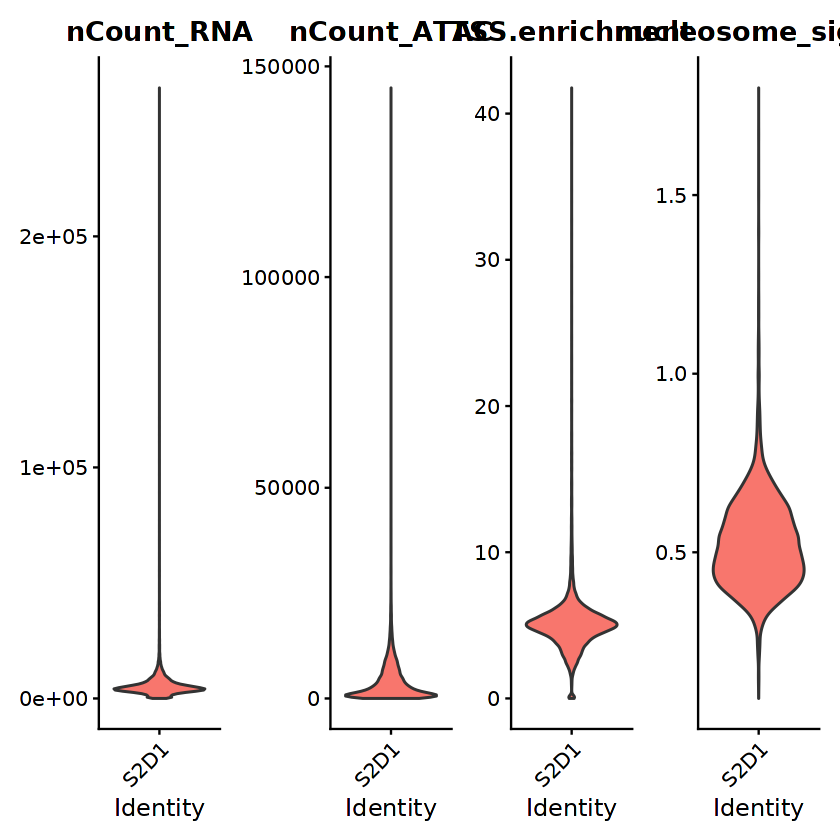

Saving 8 x 6.67 in image


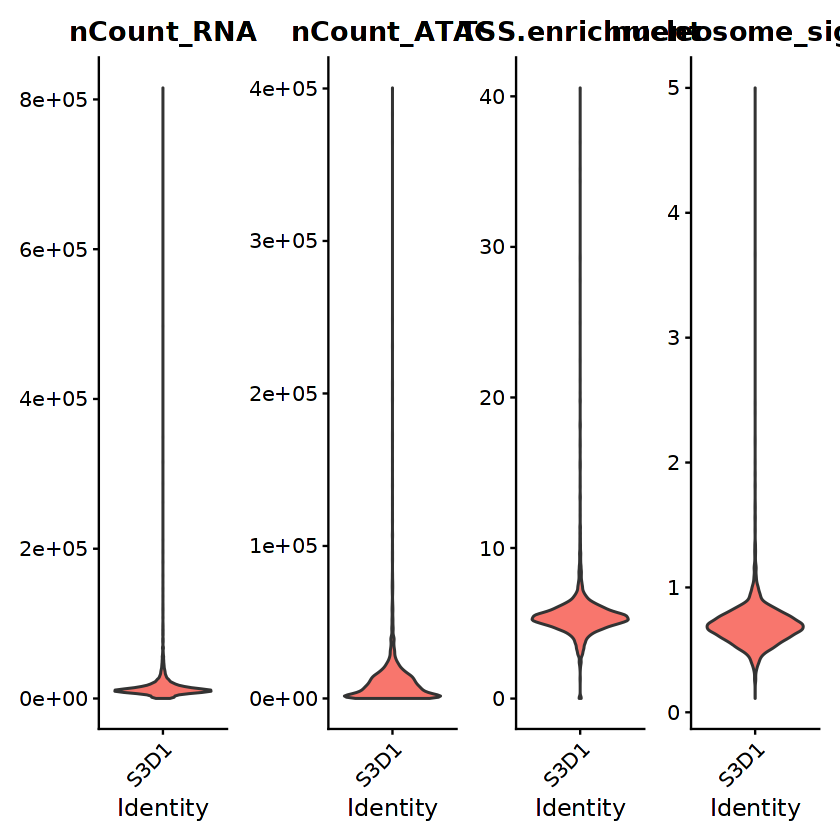

Saving 8 x 6.67 in image


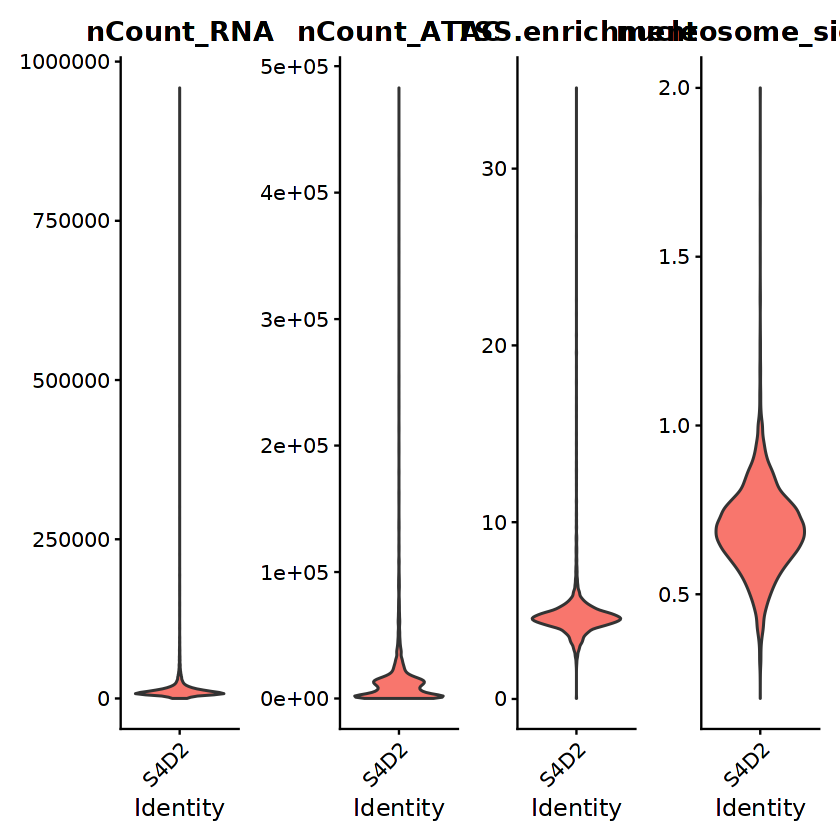

Saving 8 x 6.67 in image


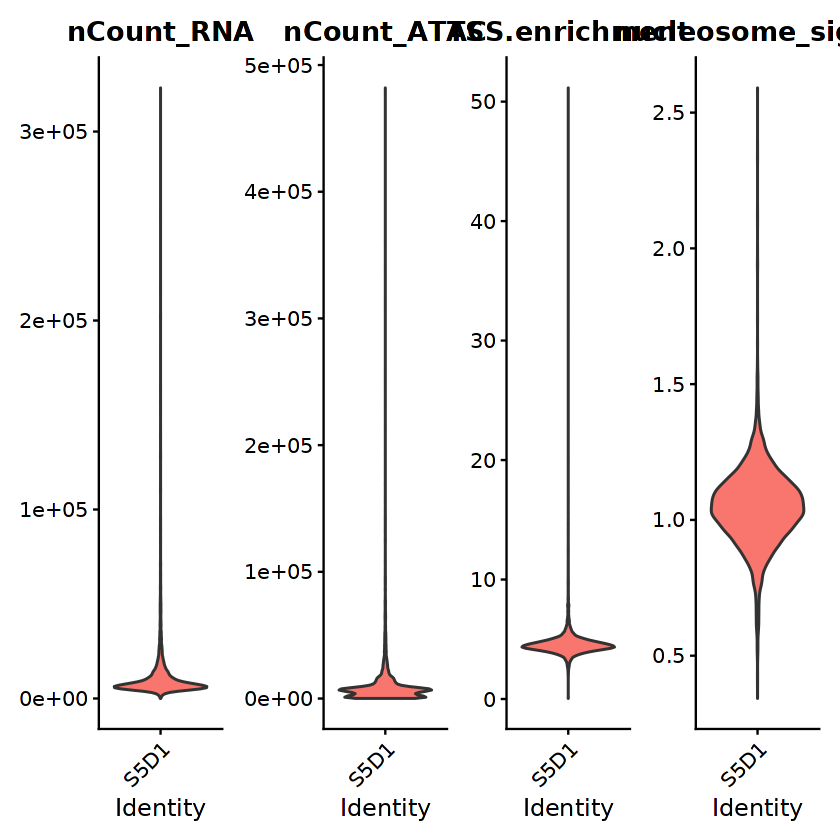

Saving 8 x 6.67 in image


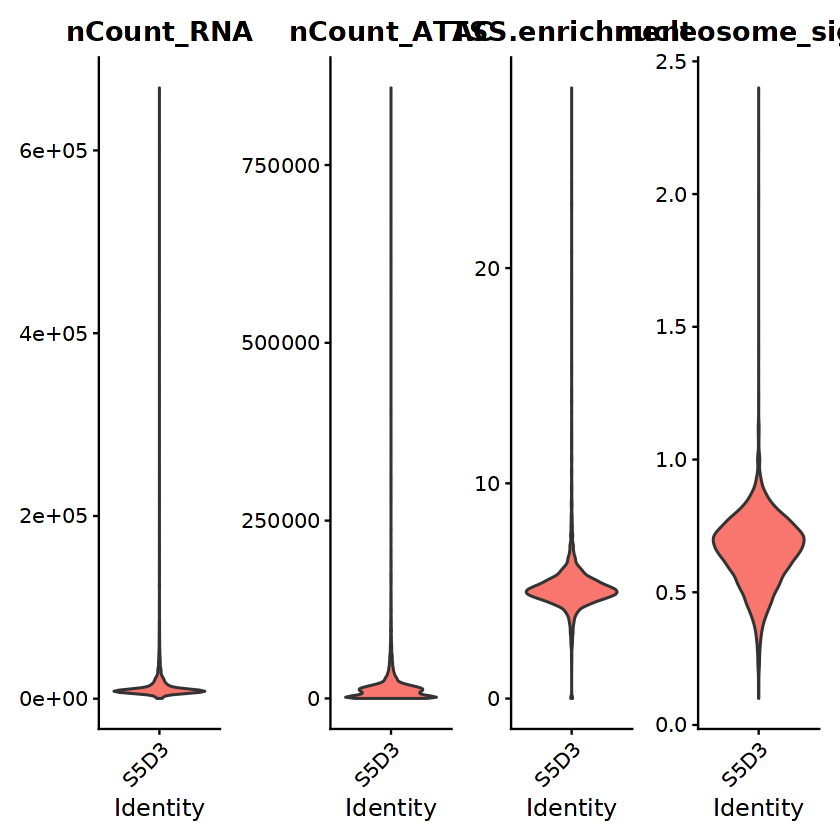

Saving 8 x 6.67 in image


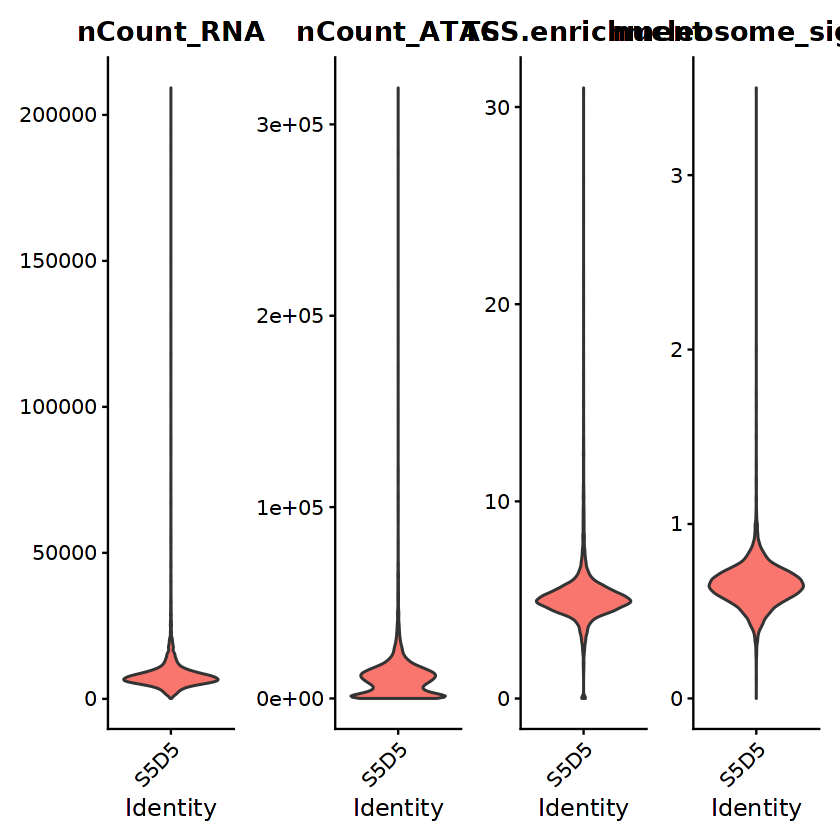

Saving 8 x 6.67 in image
Warning message:
"Removed 8 rows containing non-finite outside the scale range
(`stat_ydensity()`)."


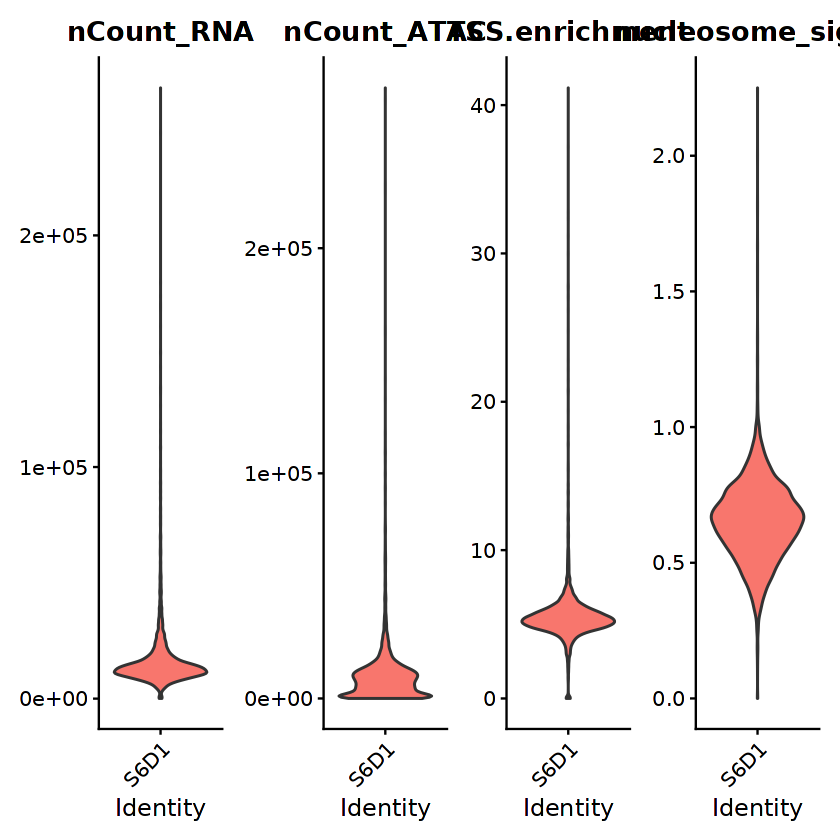

Saving 8 x 6.67 in image
Warning message:
"Removed 8 rows containing non-finite outside the scale range
(`stat_ydensity()`)."
Warning message:
"Removed 1 row containing non-finite outside the scale range
(`stat_ydensity()`)."


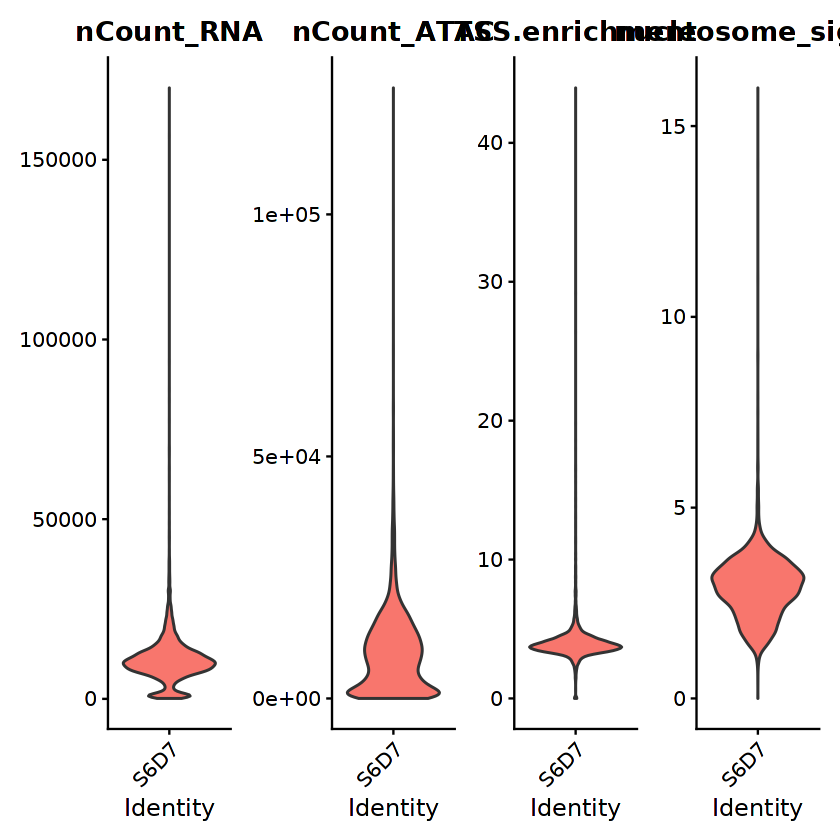

Saving 8 x 6.67 in image
Warning message:
"Removed 1 row containing non-finite outside the scale range
(`stat_ydensity()`)."


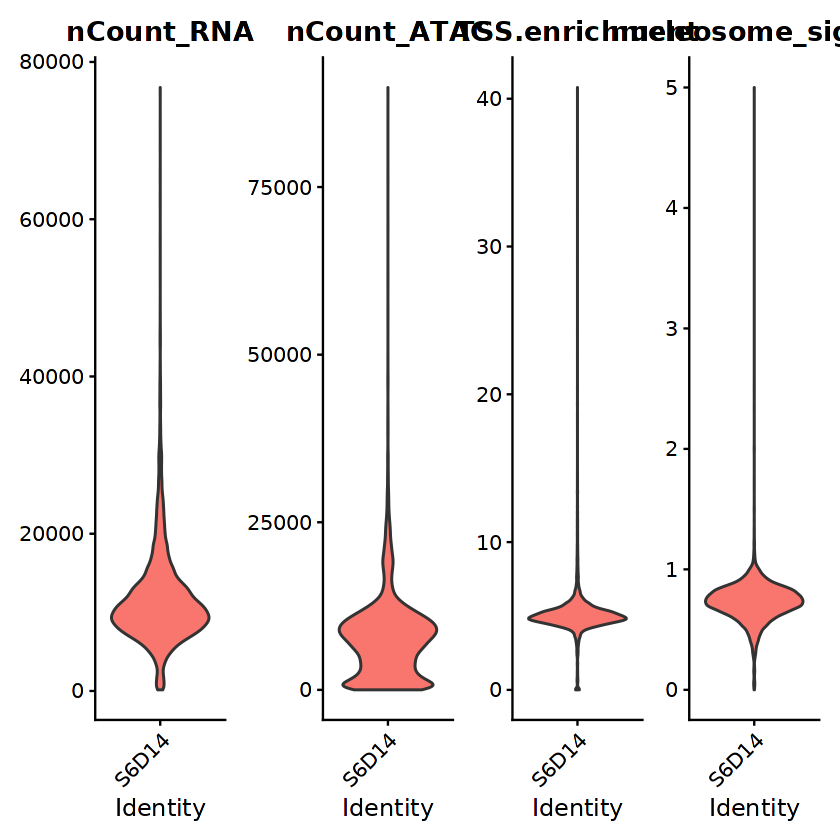

In [14]:
# Save QC metric plots before filtering
VlnPlot(object = s2d1,features = c("nCount_RNA", "nCount_ATAC", "TSS.enrichment", "nucleosome_signal"),ncol = 4,pt.size = 0)
ggsave("outputs/QC/S2D1_preQC.png", width = 8)

VlnPlot(object = s3d1,features = c("nCount_RNA", "nCount_ATAC", "TSS.enrichment", "nucleosome_signal"),ncol = 4,pt.size = 0)
ggsave("outputs/QC/S3D1_preQC.png", width = 8)

VlnPlot(object = s4d2,features = c("nCount_RNA", "nCount_ATAC", "TSS.enrichment", "nucleosome_signal"),ncol = 4,pt.size = 0)
ggsave("outputs/QC/S4D2_preQC.png", width = 8)

VlnPlot(object = s5d1,features = c("nCount_RNA", "nCount_ATAC", "TSS.enrichment", "nucleosome_signal"),ncol = 4,pt.size = 0)
ggsave("outputs/QC/S5D1_preQC.png", width = 8)

VlnPlot(object = s5d3,features = c("nCount_RNA", "nCount_ATAC", "TSS.enrichment", "nucleosome_signal"),ncol = 4,pt.size = 0)
ggsave("outputs/QC/S5D3_preQC.png", width = 8)

VlnPlot(object = s5d5,features = c("nCount_RNA", "nCount_ATAC", "TSS.enrichment", "nucleosome_signal"),ncol = 4,pt.size = 0)
ggsave("outputs/QC/S5D5_preQC.png", width = 8)

VlnPlot(object = s6d1,features = c("nCount_RNA", "nCount_ATAC", "TSS.enrichment", "nucleosome_signal"),ncol = 4,pt.size = 0)
ggsave("outputs/QC/S6D1_preQC.png", width = 8)

VlnPlot(object = s6d7,features = c("nCount_RNA", "nCount_ATAC", "TSS.enrichment", "nucleosome_signal"),ncol = 4,pt.size = 0)
ggsave("outputs/QC/S6D7_preQC.png", width = 8)

VlnPlot(object = s6d14,features = c("nCount_RNA", "nCount_ATAC", "TSS.enrichment", "nucleosome_signal"),ncol = 4,pt.size = 0)
ggsave("outputs/QC/S6D14_preQC.png", width = 8)

In [15]:
#Quality Control Filtering
s2d1 <- subset(x = s2d1,subset = nCount_ATAC < 40000 & nCount_RNA < 40000 & nCount_ATAC > 1000 & nCount_RNA > 1000 & nucleosome_signal < 1.5 & TSS.enrichment > 2)
s3d1 <- subset(x = s3d1,subset = nCount_ATAC < 40000 & nCount_RNA < 40000 & nCount_ATAC > 1000 & nCount_RNA > 1000 & nucleosome_signal < 1.5 & TSS.enrichment > 2)
s4d2 <- subset(x = s4d2,subset = nCount_ATAC < 40000 & nCount_RNA < 40000 & nCount_ATAC > 1000 & nCount_RNA > 1000 & nucleosome_signal < 1.5 & TSS.enrichment > 2)
s5d1 <- subset(x = s5d1,subset = nCount_ATAC < 40000 & nCount_RNA < 40000 & nCount_ATAC > 1000 & nCount_RNA > 1000 & nucleosome_signal < 1.5 & TSS.enrichment > 2)
s5d3 <- subset(x = s5d3,subset = nCount_ATAC < 40000 & nCount_RNA < 40000 & nCount_ATAC > 1000 & nCount_RNA > 1000 & nucleosome_signal < 1.5 & TSS.enrichment > 2)
s5d5 <- subset(x = s5d5,subset = nCount_ATAC < 40000 & nCount_RNA < 40000 & nCount_ATAC > 1000 & nCount_RNA > 1000 & nucleosome_signal < 1.5 & TSS.enrichment > 2)
s6d1 <- subset(x = s6d1,subset = nCount_ATAC < 40000 & nCount_RNA < 40000 & nCount_ATAC > 1000 & nCount_RNA > 1000 & nucleosome_signal < 1.5 & TSS.enrichment > 2)
s6d7 <- subset(x = s6d7,subset = nCount_ATAC < 40000 & nCount_RNA < 40000 & nCount_ATAC > 1000 & nCount_RNA > 1000 & nucleosome_signal < 5 & TSS.enrichment > 2)
s6d14 <- subset(x = s6d14,subset = nCount_ATAC < 40000 & nCount_RNA < 40000 & nCount_ATAC > 1000 & nCount_RNA > 1000 & nucleosome_signal < 5 & TSS.enrichment > 2)

Saving 8 x 6.67 in image


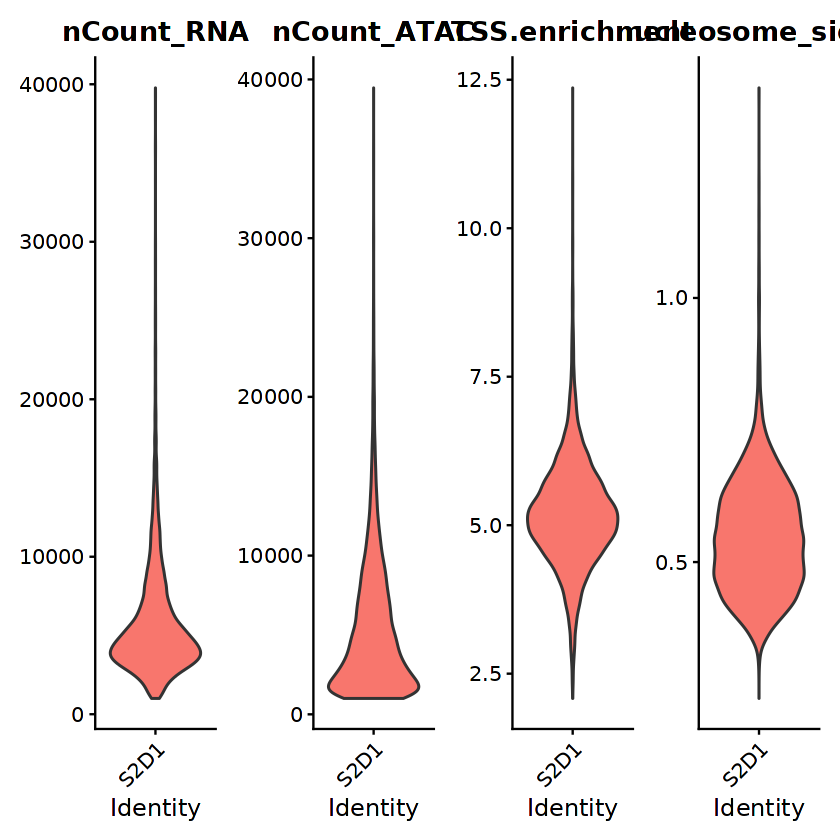

Saving 8 x 6.67 in image


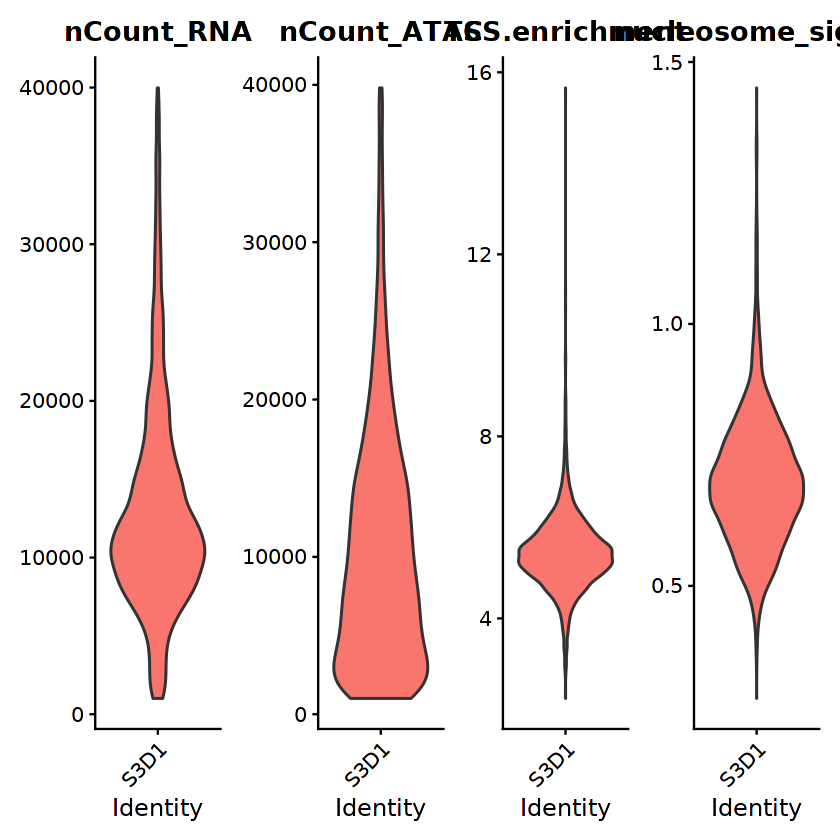

Saving 8 x 6.67 in image


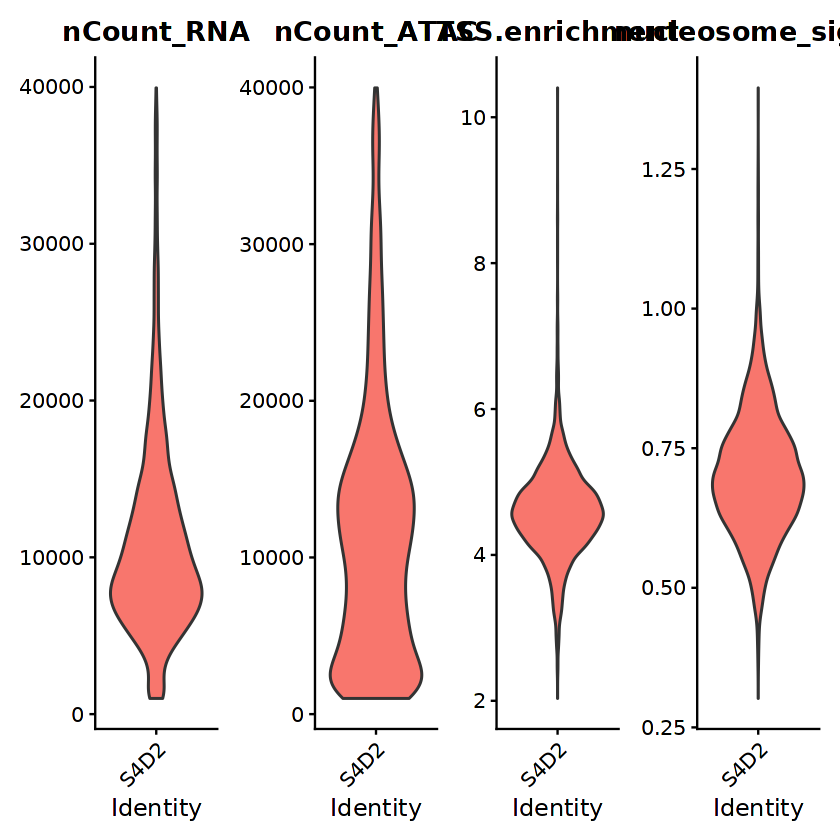

Saving 8 x 6.67 in image


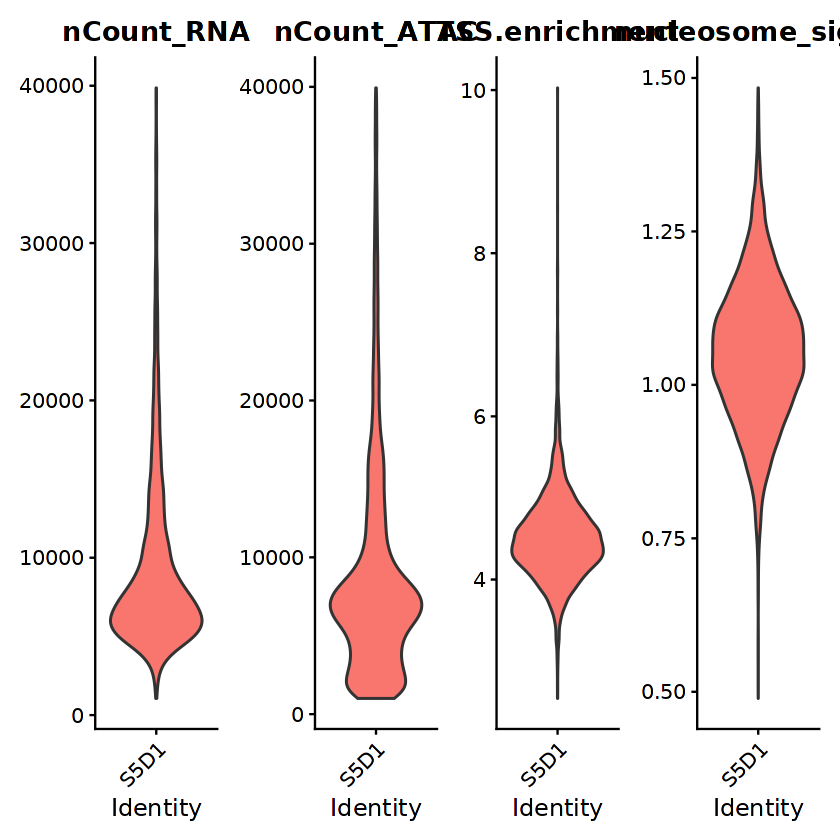

Saving 8 x 6.67 in image


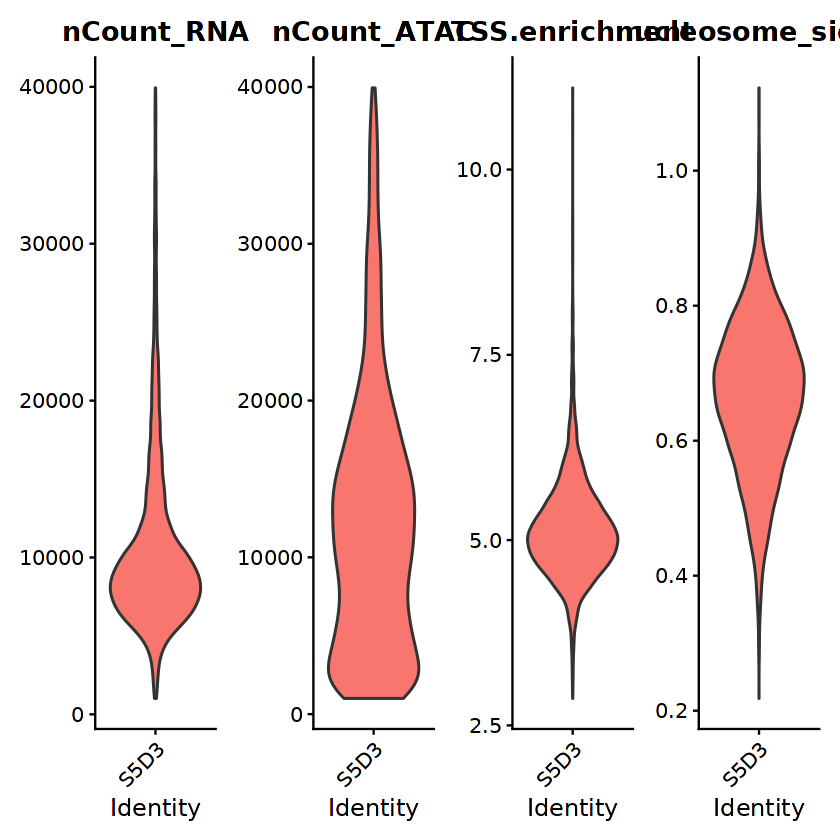

Saving 8 x 6.67 in image


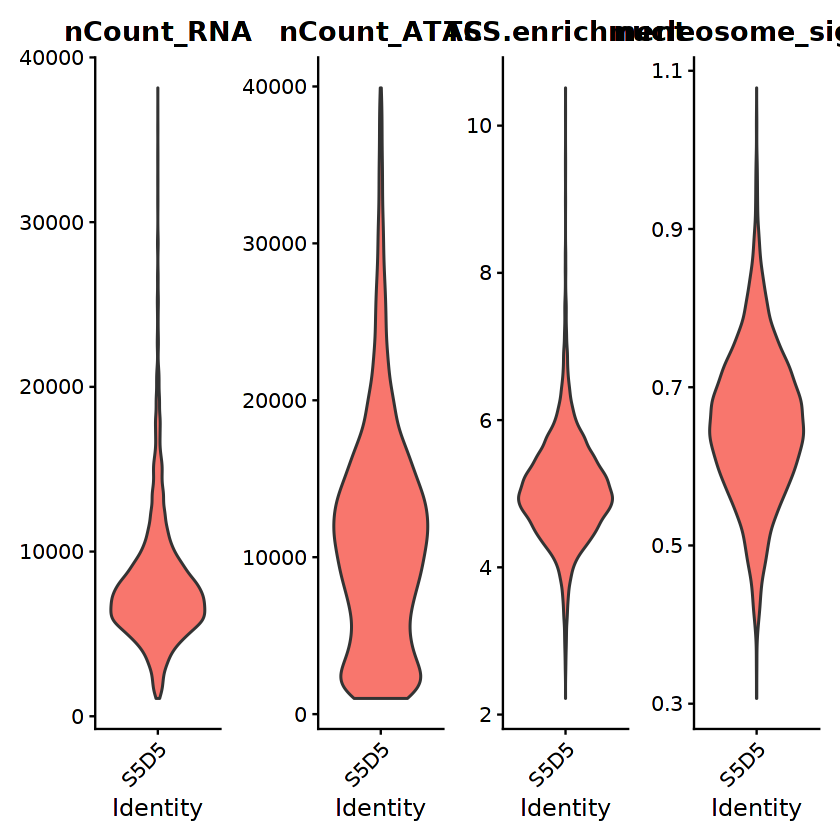

Saving 8 x 6.67 in image


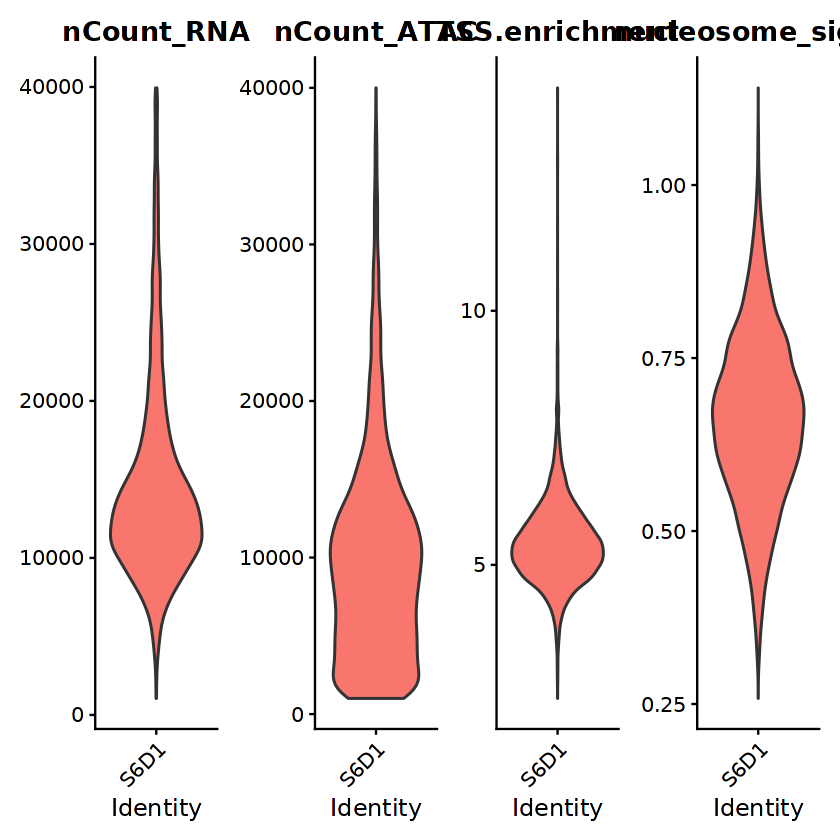

Saving 8 x 6.67 in image


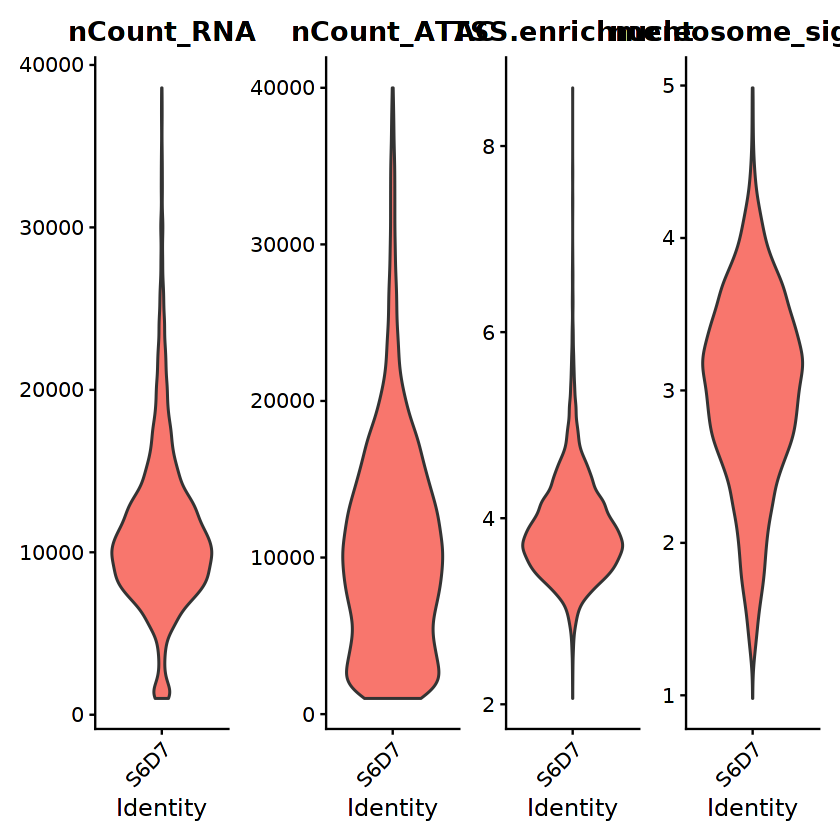

Saving 8 x 6.67 in image


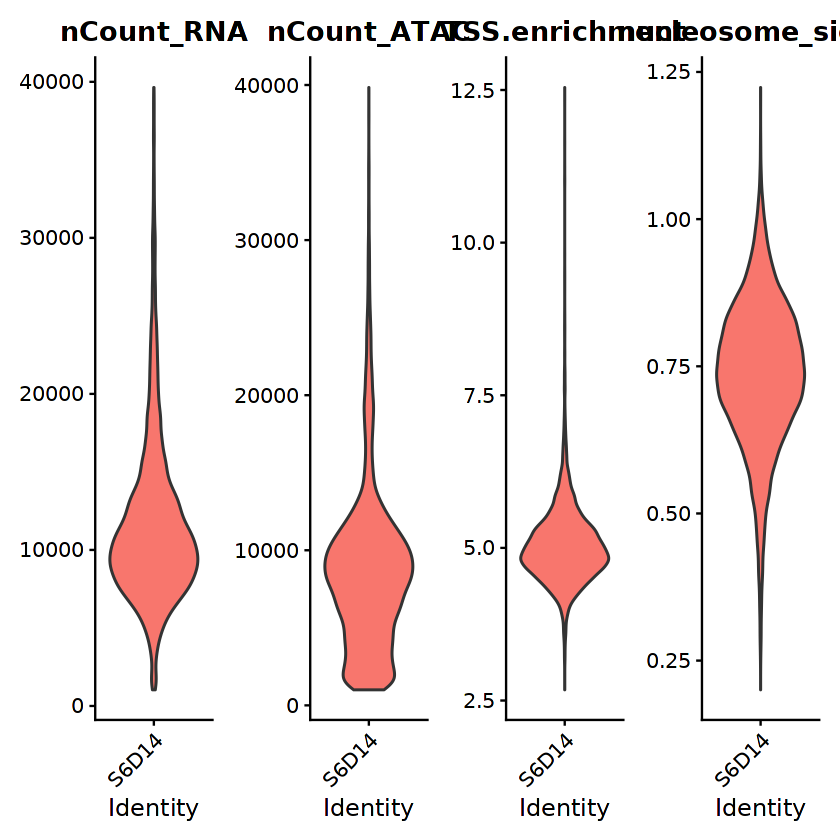

In [16]:
# Save QC metric plots after filtering
VlnPlot(object = s2d1,features = c("nCount_RNA", "nCount_ATAC", "TSS.enrichment", "nucleosome_signal"),ncol = 4,pt.size = 0)
ggsave("outputs/QC/S2D1_postQC.png", width = 8)

VlnPlot(object = s3d1,features = c("nCount_RNA", "nCount_ATAC", "TSS.enrichment", "nucleosome_signal"),ncol = 4,pt.size = 0)
ggsave("outputs/QC/S3D1_postQC.png", width = 8)

VlnPlot(object = s4d2,features = c("nCount_RNA", "nCount_ATAC", "TSS.enrichment", "nucleosome_signal"),ncol = 4,pt.size = 0)
ggsave("outputs/QC/S4D2_postQC.png", width = 8)

VlnPlot(object = s5d1,features = c("nCount_RNA", "nCount_ATAC", "TSS.enrichment", "nucleosome_signal"),ncol = 4,pt.size = 0)
ggsave("outputs/QC/S5D1_postQC.png", width = 8)

VlnPlot(object = s5d3,features = c("nCount_RNA", "nCount_ATAC", "TSS.enrichment", "nucleosome_signal"),ncol = 4,pt.size = 0)
ggsave("outputs/QC/S5D3_postQC.png", width = 8)

VlnPlot(object = s5d5,features = c("nCount_RNA", "nCount_ATAC", "TSS.enrichment", "nucleosome_signal"),ncol = 4,pt.size = 0)
ggsave("outputs/QC/S5D5_postQC.png", width = 8)

VlnPlot(object = s6d1,features = c("nCount_RNA", "nCount_ATAC", "TSS.enrichment", "nucleosome_signal"),ncol = 4,pt.size = 0)
ggsave("outputs/QC/S6D1_postQC.png", width = 8)

VlnPlot(object = s6d7,features = c("nCount_RNA", "nCount_ATAC", "TSS.enrichment", "nucleosome_signal"),ncol = 4,pt.size = 0)
ggsave("outputs/QC/S6D7_postQC.png", width = 8)

VlnPlot(object = s6d14,features = c("nCount_RNA", "nCount_ATAC", "TSS.enrichment", "nucleosome_signal"),ncol = 4,pt.size = 0)
ggsave("outputs/QC/S6D14_postQC.png", width = 8)

# Process individual datasets

## S2D1

In [17]:
#S2D1
# call peaks using MACS2
peaks.s2d1 <- CallPeaks(s2d1 , macs2.path = "/storage1/fs1/jmillman/Active/Matt/R_libraries/Conda/envs/PeakCalling_analysis/bin/macs2")

# remove peaks on nonstandard chromosomes and in genomic blacklist regions
peaks.s2d1 <- keepStandardChromosomes(peaks.s2d1, pruning.mode = "coarse")
peaks.s2d1 <- subsetByOverlaps(x = peaks.s2d1, ranges = blacklist_hg38_unified, invert = TRUE)

# quantify counts in each peak
macs2counts.s2d1 <- FeatureMatrix(fragments = Fragments(s2d1), features = peaks.s2d1, cells = colnames(s2d1))

# create a new assay using the MACS2 peak set and add it to the Seurat object
s2d1[["peaks"]] <- CreateChromatinAssay(counts = macs2counts.s2d1, fragments = frags.s2d1, annotation = annotation)

Extracting reads overlapping genomic regions



In [18]:
#Normalization and dimensional reduction
DefaultAssay(s2d1) <- "RNA"

s2d1 <- NormalizeData(s2d1, normalization.method = "LogNormalize", scale.factor = 10000)
s2d1 <- FindVariableFeatures(s2d1, selection.method = "vst", nfeatures = 2000)
s2d1 <- ScaleData(s2d1, features = rownames(s2d1))
s2d1 <- RunPCA(s2d1)

DefaultAssay(s2d1) <- "peaks"
s2d1 <- FindTopFeatures(s2d1, min.cutoff = 5)
s2d1 <- RunTFIDF(s2d1)
s2d1 <- RunSVD(s2d1)

# build a joint neighbor graph using both assays
s2d1 <- FindMultiModalNeighbors(object = s2d1,reduction.list = list("pca", "lsi"), dims.list = list(1:50, 2:40),modality.weight.name = "RNA.weight", verbose = FALSE)

# build a joint UMAP visualization
s2d1 <- RunUMAP(object = s2d1, nn.name = "weighted.nn",assay = "RNA",verbose = FALSE)
s2d1 <- FindClusters(s2d1, graph.name = "wsnn", verbose = FALSE, resolution = 0.4, cluster.name = "wnn_clusters")

# get cluster markers
DefaultAssay(s2d1) <- "RNA"
cluster.markers <- FindAllMarkers(object = s2d1, group.by = "wnn_clusters", only.pos = TRUE)
write.csv(cluster.markers, file = "outputs/ClusterMarkers/MultiomeS2D1_wnnclustermarkers.csv")

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

PC_ 1 
Positive:  KIF18B, ARHGAP11B, MELK, LINC01572, DLEU2, CEP128, KIF18A, KIF14, BRIP1, RFC3 
	   MIS18BP1, RTKN2, MMS22L, DEPDC1B, FANCI, POLQ, CENPI, NEIL3, PIF1, CENPK 
	   ATAD5, PBX3, KIF23, KIF11, BUB1B, BUB1, Z94721.1, MYEF2, MIR924HG, RRM2 
Negative:  LEFTY2, HSPA5, PLSCR2, ERBB4, ERO1B, CCL2, AC092640.1, LINC01504, PRSS2, HMGCS1 
	   PRSS1, CCDC141, ADGRG7, DSCAM, GYPB, CD70, AC055788.1, FDFT1, AC008050.1, LINC00326 
	   IGFBP5, AC069185.1, AC004949.1, AC136489.1, AC017074.1, AL590434.1, RSPO2, AC116903.2, AL356022.1, FTL 
PC_ 2 
Positive:  ASPM, CENPF, MKI67, TOP2A, TPX2, CENPE, HMMR, KIF14, CCNB1, ARL6IP1 
	   KNL1, NUSAP1, ANLN, SGO2, KPNA2, KIF20B, BUB1, TACC3, GTSE1, KIF2C 
	   NUF2, KIF23, BUB1B, MIS18BP1, AURKA, PRC1, DEPDC1, KIF18B, KIF18A, NDC80 
Negative:  GRID2, XACT, AC068051.1, ANK2, AL050309.1, TTN, UNC13C, IMMP2L, LRRTM4, RIMS2 
	   GPC6, LINC01090, ZDHHC

In [20]:
# Motif Analysis
DefaultAssay(s2d1) <- "peaks"

# extract position frequency matrices for the motifs
sq24 <- RSQLite::dbConnect(RSQLite::SQLite(), db(JASPAR2024()))
pwm <- getMatrixSet(x = sq24,opts = list(species = 9606, all_versions = FALSE))

# add motif information
s2d1 <- AddMotifs(s2d1, genome = BSgenome.Hsapiens.UCSC.hg38, pfm = pwm)

# add genome info
genome(s2d1) <- "hg38"

# Computing motif activities
s2d1 <- RunChromVAR(object = s2d1, genome = BSgenome.Hsapiens.UCSC.hg38)

#Check differential motif activity by cluster
DefaultAssay(s2d1) <- 'chromvar'
Idents(s2d1) <- "wnn_clusters"

differential.activity <- FindAllMarkers(object = s2d1, only.pos = TRUE, test.use = 'LR', latent.vars = 'nCount_peaks',slot = "data")
convertIDlist <- ConvertMotifID(object = s2d1,id = rownames(differential.activity),assay='peaks')
differential.activity <- cbind(differential.activity,convertIDlist)
write.csv(differential.activity, file = "outputs/ClusterMarkers/MultiomeS2D1_wnnclustermotifs.csv", row.names = TRUE)

Building motif matrix

Finding motif positions

Creating Motif object

Warning message in CreateMotifObject(data = motif.matrix, positions = motif.positions, :
"Non-unique motif names supplied, making unique"
Computing GC bias per region

Selecting background regions

Computing deviations from background

Constructing chromVAR assay

Warning message:
"Layer counts isn't present in the assay object; returning NULL"
Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 7

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"


In [21]:
####CHECKPOINT####
saveRDS(s2d1, file="checkpoints/MultiomeS2D1.rds")
rm(peaks.s2d1)
rm(macs2counts.s2d1)
rm(frags.s2d1)
rm(pwm)
rm(differential.activity)
rm(convertIDlist)
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,18673082,997.3,39627410,2116.4,39627410,2116.4
Vcells,2931090695,22362.5,4955204888,37805.3,4955199493,37805.2


## S3D1

In [22]:
#S3D1
# call peaks using MACS2
peaks.s3d1 <- CallPeaks(s3d1 , macs2.path = "/storage1/fs1/jmillman/Active/Matt/R_libraries/Conda/envs/PeakCalling_analysis/bin/macs2")

# remove peaks on nonstandard chromosomes and in genomic blacklist regions
peaks.s3d1 <- keepStandardChromosomes(peaks.s3d1, pruning.mode = "coarse")
peaks.s3d1 <- subsetByOverlaps(x = peaks.s3d1, ranges = blacklist_hg38_unified, invert = TRUE)

# quantify counts in each peak
macs2counts.s3d1 <- FeatureMatrix(fragments = Fragments(s3d1), features = peaks.s3d1, cells = colnames(s3d1))

# create a new assay using the MACS2 peak set and add it to the Seurat object
s3d1[["peaks"]] <- CreateChromatinAssay(counts = macs2counts.s3d1, fragments = frags.s3d1, annotation = annotation)

Extracting reads overlapping genomic regions



In [23]:
#Normalization and dimensional reduction
DefaultAssay(s3d1) <- "RNA"

s3d1 <- NormalizeData(s3d1, normalization.method = "LogNormalize", scale.factor = 10000)
s3d1 <- FindVariableFeatures(s3d1, selection.method = "vst", nfeatures = 2000)
s3d1 <- ScaleData(s3d1, features = rownames(s3d1))
s3d1 <- RunPCA(s3d1)

DefaultAssay(s3d1) <- "peaks"
s3d1 <- FindTopFeatures(s3d1, min.cutoff = 5)
s3d1 <- RunTFIDF(s3d1)
s3d1 <- RunSVD(s3d1)

# build a joint neighbor graph using both assays
s3d1 <- FindMultiModalNeighbors(object = s3d1,reduction.list = list("pca", "lsi"), dims.list = list(1:50, 2:40),modality.weight.name = "RNA.weight", verbose = FALSE)

# build a joint UMAP visualization
s3d1 <- RunUMAP(object = s3d1, nn.name = "weighted.nn",assay = "RNA",verbose = FALSE)
s3d1 <- FindClusters(s3d1, graph.name = "wsnn", verbose = FALSE, resolution = 0.4, cluster.name = "wnn_clusters")

# get cluster markers
DefaultAssay(s3d1) <- "RNA"
cluster.markers <- FindAllMarkers(object = s3d1, group.by = "wnn_clusters", only.pos = TRUE)
write.csv(cluster.markers, file = "outputs/ClusterMarkers/MultiomeS3D1_wnnclustermarkers.csv")

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

PC_ 1 
Positive:  FN1, ARHGAP24, DIAPH3, LINC01572, CEP128, BRIP1, LINC01515, TTN, CNKSR2, MMS22L 
	   C21orf58, CCDC18, CIT, ASPM, TNIK, RTKN2, MELK, CENPF, POLQ, KIF18B 
	   SLIT3, DEPDC1B, KLF12, RFC3, CDK1, LYPD6B, ECT2, NRCAM, Z94721.1, KIF4A 
Negative:  JUN, AL110292.1, SOX4, AL357153.2, CYP26A1, ABCA5, H1F0, NUDT4, LINC02680, GPATCH11 
	   SARS, PMAIP1, NIBAN1, DTNA, SOX17, PCDH8, ETS2, AL132718.1, DENND4A, LRIG3 
	   EIF1, NEAT1, BBC3, ANKRD33B, SQSTM1, RPL26, RPS18, RPS12, RPL13, RPS8 
PC_ 2 
Positive:  AL110292.1, DTNA, AL357153.2, NEAT1, LSAMP, DLEU2, XACT, NIBAN1, FMNL2, MACROD2 
	   ABCA5, ARHGAP21, CELF2, PTPRJ, SLC2A13, DIAPH3, ITGAV, NECTIN3, RIMS2, AL353138.1 
	   AL132718.1, EPB41L4A, LRIG3, AC017101.1, EFNA5, TSPAN5, AC044810.2, DENND4A, CCBE1, FAM155A 
Negative:  TMSB10, RPS11, RPL13A, RPS18, RPL13, RPL31, RPS27, RPL37, RPS20, EEF1A1 
	   RPL17, RPS3A, RPL32, RP

In [24]:
# Motif Analysis
DefaultAssay(s3d1) <- "peaks"

# extract position frequency matrices for the motifs
sq24 <- RSQLite::dbConnect(RSQLite::SQLite(), db(JASPAR2024()))
pwm <- getMatrixSet(x = sq24,opts = list(species = 9606, all_versions = FALSE))

# add motif information
s3d1 <- AddMotifs(s3d1, genome = BSgenome.Hsapiens.UCSC.hg38, pfm = pwm)

# add genome info
genome(s3d1) <- "hg38"

# Computing motif activities
s3d1 <- RunChromVAR(object = s3d1, genome = BSgenome.Hsapiens.UCSC.hg38)

#Check differential motif activity by cluster
DefaultAssay(s3d1) <- 'chromvar'
Idents(s3d1) <- "wnn_clusters"

differential.activity <- FindAllMarkers(object = s3d1, only.pos = TRUE, test.use = 'LR', latent.vars = 'nCount_peaks',slot = "data")
convertIDlist <- ConvertMotifID(object = s3d1,id = rownames(differential.activity),assay='peaks')
differential.activity <- cbind(differential.activity,convertIDlist)
write.csv(differential.activity, file = "outputs/ClusterMarkers/MultiomeS3D1_wnnclustermotifs.csv", row.names = TRUE)

Building motif matrix

Finding motif positions

Creating Motif object

Warning message in CreateMotifObject(data = motif.matrix, positions = motif.positions, :
"Non-unique motif names supplied, making unique"
Computing GC bias per region

Selecting background regions

Computing deviations from background

Constructing chromVAR assay

Warning message:
"Layer counts isn't present in the assay object; returning NULL"
Calculating cluster 0

Calculating cluster 1

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 2

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 3

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 4

Calculating cluster 5

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 6



In [25]:
####CHECKPOINT####
saveRDS(s3d1, file="checkpoints/MultiomeS3D1.rds")
rm(peaks.s3d1)
rm(macs2counts.s3d1)
rm(frags.s3d1)
rm(pwm)
rm(differential.activity)
rm(convertIDlist)
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,18873702,1008,39627410,2116.4,39627410,2116.4
Vcells,3292394798,25119,4955204888,37805.3,4955204489,37805.3


## S4D2

In [26]:
#S4D2
# call peaks using MACS2
peaks.s4d2 <- CallPeaks(s4d2, macs2.path = "/storage1/fs1/jmillman/Active/Matt/R_libraries/Conda/envs/PeakCalling_analysis/bin/macs2")

# remove peaks on nonstandard chromosomes and in genomic blacklist regions
peaks.s4d2 <- keepStandardChromosomes(peaks.s4d2, pruning.mode = "coarse")
peaks.s4d2 <- subsetByOverlaps(x = peaks.s4d2, ranges = blacklist_hg38_unified, invert = TRUE)

# quantify counts in each peak
macs2counts.s4d2 <- FeatureMatrix(fragments = Fragments(s4d2), features = peaks.s4d2, cells = colnames(s4d2))

# create a new assay using the MACS2 peak set and add it to the Seurat object
s4d2[["peaks"]] <- CreateChromatinAssay(counts = macs2counts.s4d2, fragments = frags.s4d2, annotation = annotation)

Extracting reads overlapping genomic regions



In [27]:
#Normalization and dimensional reduction
DefaultAssay(s4d2) <- "RNA"

s4d2 <- NormalizeData(s4d2, normalization.method = "LogNormalize", scale.factor = 10000)
s4d2 <- FindVariableFeatures(s4d2, selection.method = "vst", nfeatures = 2000)
s4d2 <- ScaleData(s4d2, features = rownames(s4d2))
s4d2 <- RunPCA(s4d2)

DefaultAssay(s4d2) <- "peaks"
s4d2 <- FindTopFeatures(s4d2, min.cutoff = 5)
s4d2 <- RunTFIDF(s4d2)
s4d2 <- RunSVD(s4d2)

# build a joint neighbor graph using both assays
s4d2 <- FindMultiModalNeighbors(object = s4d2,reduction.list = list("pca", "lsi"), dims.list = list(1:50, 2:40),modality.weight.name = "RNA.weight", verbose = FALSE)

# build a joint UMAP visualization
s4d2 <- RunUMAP(object = s4d2, nn.name = "weighted.nn",assay = "RNA",verbose = FALSE)
s4d2 <- FindClusters(s4d2, graph.name = "wsnn", verbose = FALSE, resolution = 0.4, cluster.name = "wnn_clusters")

DefaultAssay(s4d2) <- "RNA"
cluster.markers <- FindAllMarkers(object = s4d2, group.by = "wnn_clusters", only.pos = TRUE)
write.csv(cluster.markers, file = "outputs/ClusterMarkers/MultiomeS4D2_wnnclustermarkers.csv")

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

PC_ 1 
Positive:  DIAPH3, POLQ, CIT, ANLN, BUB1B, KIF14, BUB1, KIF18A, CDC25C, RTKN2 
	   CIP2A, ARHGAP11B, KIF4A, TOP2A, KIF20B, CENPE, KIF11, BRIP1, CDCA2, ECT2 
	   KIF18B, MELK, NDC80, GTSE1, KIF15, RRM2, SMC4, CENPI, STIL, SPC25 
Negative:  DNAH7, EEF1A1, RPS11, RPL13, RPS12, RPL26, RPL23, RPL17, RPL37, RPS3A 
	   RPL32, RPL37A, RPL41, RPS15A, TPT1, RPS8, RPS24, RPS20, RPS27, RPL28 
	   RPL31, RPLP1, RPS6, RPS15, RPS25, RPL23A, RPL36A, RPL38, FTH1, RPL4 
PC_ 2 
Positive:  EEF1A1, RPL13, RPS12, TPT1, RPL41, RPS3A, RPL23, RPL37A, RPL32, RPLP1 
	   RPS11, RPL26, RPL17, RPS8, RPS24, RPL37, RPS20, RPS15A, RPL31, RPS6 
	   RPL23A, RPS27, RPS25, RPL28, RPS15, RPL36A, PTMA, RPLP0, TMSB10, RPL38 
Negative:  DACH1, PLCL1, SPOCK1, EDIL3, LMO3, DNAH7, MAST4, CSMD3, STXBP5L, RGS6 
	   LRP1B, KCTD8, CNTNAP2, KCNH7, MACROD2, LINGO2, LSAMP, RGS7, TOX, ANGPT2 
	   GABRB3, MMP16, ADGRL3, PAM, L

In [28]:
# Motif Analysis
DefaultAssay(s4d2) <- "peaks"

# extract position frequency matrices for the motifs
sq24 <- RSQLite::dbConnect(RSQLite::SQLite(), db(JASPAR2024()))
pwm <- getMatrixSet(x = sq24,opts = list(species = 9606, all_versions = FALSE))

# add motif information
s4d2 <- AddMotifs(s4d2, genome = BSgenome.Hsapiens.UCSC.hg38, pfm = pwm)

# add genome info
genome(s4d2) <- "hg38"

# Computing motif activities
s4d2 <- RunChromVAR(object = s4d2, genome = BSgenome.Hsapiens.UCSC.hg38)

#Check differential motif activity by cluster
DefaultAssay(s4d2) <- 'chromvar'
Idents(s4d2) <- "wnn_clusters"

differential.activity <- FindAllMarkers(object = s4d2, only.pos = TRUE, test.use = 'LR', latent.vars = 'nCount_peaks',slot = "data")
convertIDlist <- ConvertMotifID(object = s4d2,id = rownames(differential.activity),assay='peaks')
differential.activity <- cbind(differential.activity,convertIDlist)
write.csv(differential.activity, file = "outputs/ClusterMarkers/MultiomeS4D2_wnnclustermotifs.csv", row.names = TRUE)

Building motif matrix

Finding motif positions

Creating Motif object

Warning message in CreateMotifObject(data = motif.matrix, positions = motif.positions, :
"Non-unique motif names supplied, making unique"
Computing GC bias per region

Selecting background regions

Computing deviations from background

Constructing chromVAR assay

Warning message:
"Layer counts isn't present in the assay object; returning NULL"
Calculating cluster 0

Calculating cluster 1

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 2

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 3

Calculating cluster 4

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 5

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 6

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs p

In [29]:
####CHECKPOINT####
saveRDS(s4d2, file="checkpoints/MultiomeS4D2.rds")
rm(peaks.s4d2)
rm(macs2counts.s4d2)
rm(frags.s4d2)
rm(pwm)
rm(differential.activity)
rm(convertIDlist)
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,19083300,1019.2,39627410,2116.4,39627410,2116.4
Vcells,3738331937,28521.3,5946325865,45366.9,5946324247,45366.9


## S5D1

In [30]:
#S5D1
# call peaks using MACS2
peaks.s5d1 <- CallPeaks(s5d1, macs2.path = "/storage1/fs1/jmillman/Active/Matt/R_libraries/Conda/envs/PeakCalling_analysis/bin/macs2")

# remove peaks on nonstandard chromosomes and in genomic blacklist regions
peaks.s5d1 <- keepStandardChromosomes(peaks.s5d1, pruning.mode = "coarse")
peaks.s5d1 <- subsetByOverlaps(x = peaks.s5d1, ranges = blacklist_hg38_unified, invert = TRUE)

# quantify counts in each peak
macs2counts.s5d1 <- FeatureMatrix(fragments = Fragments(s5d1), features = peaks.s5d1, cells = colnames(s5d1))

# create a new assay using the MACS2 peak set and add it to the Seurat object
s5d1[["peaks"]] <- CreateChromatinAssay(counts = macs2counts.s5d1, fragments = frags.s5d1, annotation = annotation)

Extracting reads overlapping genomic regions



In [31]:
#Normalization and dimensional reduction
DefaultAssay(s5d1) <- "RNA"

s5d1 <- NormalizeData(s5d1, normalization.method = "LogNormalize", scale.factor = 10000)
s5d1 <- FindVariableFeatures(s5d1, selection.method = "vst", nfeatures = 2000)
s5d1 <- ScaleData(s5d1, features = rownames(s5d1))
s5d1 <- RunPCA(s5d1)

DefaultAssay(s5d1) <- "peaks"
s5d1 <- FindTopFeatures(s5d1, min.cutoff = 5)
s5d1 <- RunTFIDF(s5d1)
s5d1 <- RunSVD(s5d1)

# build a joint neighbor graph using both assays
s5d1 <- FindMultiModalNeighbors(object = s5d1,reduction.list = list("pca", "lsi"), dims.list = list(1:50, 2:40),modality.weight.name = "RNA.weight", verbose = FALSE)

# build a joint UMAP visualization
s5d1 <- RunUMAP(object = s5d1, nn.name = "weighted.nn",assay = "RNA",verbose = FALSE)
s5d1 <- FindClusters(s5d1, graph.name = "wsnn", verbose = FALSE, resolution = 0.4, cluster.name = "wnn_clusters")

DefaultAssay(s5d1) <- "RNA"
cluster.markers <- FindAllMarkers(object = s5d1, group.by = "wnn_clusters", only.pos = TRUE)
write.csv(cluster.markers, file = "outputs/ClusterMarkers/MultiomeS5D1_wnnclustermarkers.csv")

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

PC_ 1 
Positive:  SLC4A4, GPC3, KIAA1217, MECOM, PDE3A, GLIS3, RALYL, NHS, APOE, AGTR1 
	   AC092691.1, KCNJ3, ADGRG6, TANC1, UNC13C, NXPH2, TLN2, NEAT1, C8orf34, SOX6 
	   DTNA, CDH7, ATF7IP2, LHFPL3, KHDRBS2, SERPINA1, CDK14, SPTLC3, BACH2, SLIT3 
Negative:  ST18, KCNB2, RIMBP2, CHGA, NAV3, CACNA2D1, HEPACAM2, LINC02197, CADM2, TRPM3 
	   RUNX1T1, PTPRN2, SGCD, SCG3, RIMS2, RGS7, LINC01811, MAN1A1, SCN3A, RYR2 
	   C1QL1, ST6GALNAC5, NRXN1, GRIN3A, HECW2, MIR137HG, TOX, SLC8A1, CACNA1A, SH3RF3 
PC_ 2 
Positive:  EDIL3, AC109466.1, NLGN1, DLK1, LMO3, SLC4A4, AC008415.1, ELMO1, AGTR1, SPOCK1 
	   RGS6, GALNT17, AL139815.1, RALYL, FSTL5, DSCAM, NKAIN2, MAST4, KIAA1217, LINC00907 
	   LHFPL3, CDH10, TMEM232, SEMA6D, CDH7, SEZ6L, BNC2, SNCAIP, PCDH9, AC092691.1 
Negative:  PCDH15, AC019117.1, PRDM1, PITX2, CFTR, PIEZO2, AL353784.1, LGALS3, EPHA4, RASGEF1B 
	   SLC1A3, ZNF385B, SEMA3A,

In [32]:
# Motif Analysis
DefaultAssay(s5d1) <- "peaks"

# extract position frequency matrices for the motifs
sq24 <- RSQLite::dbConnect(RSQLite::SQLite(), db(JASPAR2024()))
pwm <- getMatrixSet(x = sq24,opts = list(species = 9606, all_versions = FALSE))

# add motif information
s5d1 <- AddMotifs(s5d1, genome = BSgenome.Hsapiens.UCSC.hg38, pfm = pwm)

# add genome info
genome(s5d1) <- "hg38"

# Computing motif activities
s5d1 <- RunChromVAR(object = s5d1, genome = BSgenome.Hsapiens.UCSC.hg38)

#Check differential motif activity by cluster
DefaultAssay(s5d1) <- 'chromvar'
Idents(s5d1) <- "wnn_clusters"

differential.activity <- FindAllMarkers(object = s5d1, only.pos = TRUE, test.use = 'LR', latent.vars = 'nCount_peaks',slot = "data")
convertIDlist <- ConvertMotifID(object = s5d1,id = rownames(differential.activity),assay='peaks')
differential.activity <- cbind(differential.activity,convertIDlist)
write.csv(differential.activity, file = "outputs/ClusterMarkers/MultiomeS5D1_wnnclustermotifs.csv", row.names = TRUE)

Building motif matrix

Finding motif positions

Creating Motif object

Warning message in CreateMotifObject(data = motif.matrix, positions = motif.positions, :
"Non-unique motif names supplied, making unique"
Computing GC bias per region

Selecting background regions

Computing deviations from background

Constructing chromVAR assay

Warning message:
"Layer counts isn't present in the assay object; returning NULL"
Calculating cluster 0

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 1

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 2

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 3

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 4

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 5

Warning messag

In [33]:
####CHECKPOINT####
saveRDS(s5d1, file="checkpoints/MultiomeS5D1.rds")
rm(peaks.s5d1)
rm(macs2counts.s5d1)
rm(frags.s5d1)
rm(pwm)
rm(differential.activity)
rm(convertIDlist)
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,19281093,1029.8,39627410,2116.4,39627410,2116.4
Vcells,4212020993,32135.2,7135671038,54440.9,5946324247,45366.9


## S5D3

In [34]:
#S5D3
# call peaks using MACS2
peaks.s5d3 <- CallPeaks(s5d3, macs2.path = "/storage1/fs1/jmillman/Active/Matt/R_libraries/Conda/envs/PeakCalling_analysis/bin/macs2")

# remove peaks on nonstandard chromosomes and in genomic blacklist regions
peaks.s5d3 <- keepStandardChromosomes(peaks.s5d3, pruning.mode = "coarse")
peaks.s5d3 <- subsetByOverlaps(x = peaks.s5d3, ranges = blacklist_hg38_unified, invert = TRUE)

# quantify counts in each peak
macs2counts.s5d3 <- FeatureMatrix(fragments = Fragments(s5d3), features = peaks.s5d3, cells = colnames(s5d3))

# create a new assay using the MACS2 peak set and add it to the Seurat object
s5d3[["peaks"]] <- CreateChromatinAssay(counts = macs2counts.s5d3, fragments = frags.s5d3, annotation = annotation)

Extracting reads overlapping genomic regions



In [35]:
#Normalization and dimensional reduction
DefaultAssay(s5d3) <- "RNA"

s5d3 <- NormalizeData(s5d3, normalization.method = "LogNormalize", scale.factor = 10000)
s5d3 <- FindVariableFeatures(s5d3, selection.method = "vst", nfeatures = 2000)
s5d3 <- ScaleData(s5d3, features = rownames(s5d3))
s5d3 <- RunPCA(s5d3)

DefaultAssay(s5d3) <- "peaks"
s5d3 <- FindTopFeatures(s5d3, min.cutoff = 5)
s5d3 <- RunTFIDF(s5d3)
s5d3 <- RunSVD(s5d3)

# build a joint neighbor graph using both assays
s5d3 <- FindMultiModalNeighbors(object = s5d3,reduction.list = list("pca", "lsi"), dims.list = list(1:50, 2:40),modality.weight.name = "RNA.weight", verbose = FALSE)

# build a joint UMAP visualization
s5d3 <- RunUMAP(object = s5d3, nn.name = "weighted.nn",assay = "RNA",verbose = FALSE)
s5d3 <- FindClusters(s5d3, graph.name = "wsnn", verbose = FALSE, resolution = 0.4, cluster.name = "wnn_clusters")

DefaultAssay(s5d3) <- "RNA"
cluster.markers <- FindAllMarkers(object = s5d3, group.by = "wnn_clusters", only.pos = TRUE)
write.csv(cluster.markers, file = "outputs/ClusterMarkers/MultiomeS5D3_wnnclustermarkers.csv")

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

PC_ 1 
Positive:  TRPM3, CADM2, ST6GALNAC5, PDE1C, PLCXD3, DCDC1, LINC01811, SYT4, CRISPLD1, GABBR2 
	   ELAVL2, FAM155A, C7, NTNG1, MAN1A1, SCG2, AP003049.2, NDST3, TMEM132B, NRXN1 
	   GALNT14, HS3ST5, AC037450.1, LRP1B, SLC8A1, CNTNAP2, ME3, FGF14, FAM135B, ERICH3 
Negative:  FRAS1, CDH6, FN1, LAMA1, PDE3A, FZD5, MAGI1, PCDH15, HEG1, MYOF 
	   CALD1, UTRN, CDK14, MTCL1, SPTLC3, RBMS3, ADGRG6, ANXA3, PTPN14, MAML2 
	   MECOM, ONECUT1, EXPH5, VIM, FGFR2, AHNAK, PDLIM1, GLYATL2, MID1, HNF1A-AS1 
PC_ 2 
Positive:  GABBR2, GALNT14, PIEZO2, CRISPLD1, DCDC1, PDE1C, CFAP299, TFPI2, AP003049.2, OCA2 
	   SYT4, NCAM2, GABRG3, OR51E1, THRB, AC019117.1, TGFB2, LINC02715, HMCN2, AL022068.1 
	   TRHDE, ARHGAP26, TBC1D30, ERICH3, NDST3, EDA, L1TD1, LINC01163, ME3, RALYL 
Negative:  ARFGEF3, SPOCK3, INS, ISL1, MAMLD1, ERO1B, NRXN1, FCHSD2, BTBD11, FAM20A 
	   STMN2, ERBB4, PRKD1, NCAM1, MAN1A1,

In [36]:
# Motif Analysis
DefaultAssay(s5d3) <- "peaks"

# extract position frequency matrices for the motifs
sq24 <- RSQLite::dbConnect(RSQLite::SQLite(), db(JASPAR2024()))
pwm <- getMatrixSet(x = sq24,opts = list(species = 9606, all_versions = FALSE))

# add motif information
s5d3 <- AddMotifs(s5d3, genome = BSgenome.Hsapiens.UCSC.hg38, pfm = pwm)

# add genome info
genome(s5d3) <- "hg38"

# Computing motif activities
s5d3 <- RunChromVAR(object = s5d3, genome = BSgenome.Hsapiens.UCSC.hg38)

#Check differential motif activity by cluster
DefaultAssay(s5d3) <- 'chromvar'
Idents(s5d3) <- "wnn_clusters"

differential.activity <- FindAllMarkers(object = s5d3, only.pos = TRUE, test.use = 'LR', latent.vars = 'nCount_peaks',slot = "data")
convertIDlist <- ConvertMotifID(object = s5d3,id = rownames(differential.activity),assay='peaks')
differential.activity <- cbind(differential.activity,convertIDlist)
write.csv(differential.activity, file = "outputs/ClusterMarkers/MultiomeS5D3_wnnclustermotifs.csv", row.names = TRUE)

Building motif matrix

Finding motif positions

Creating Motif object

Warning message in CreateMotifObject(data = motif.matrix, positions = motif.positions, :
"Non-unique motif names supplied, making unique"
Computing GC bias per region

Selecting background regions

Computing deviations from background

Constructing chromVAR assay

Warning message:
"Layer counts isn't present in the assay object; returning NULL"
Calculating cluster 0

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 1

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 2

Calculating cluster 3

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 4

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 5

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cl

In [37]:
####CHECKPOINT####
saveRDS(s5d3, file="checkpoints/MultiomeS5D3.rds")
rm(peaks.s5d3)
rm(macs2counts.s5d3)
rm(frags.s5d3)
rm(pwm)
rm(differential.activity)
rm(convertIDlist)
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,19529924,1043.1,39627410,2116.4,39627410,2116.4
Vcells,4672540711,35648.7,7135671038,54440.9,7135573525,54440.2


## S5D5

In [38]:
#S5D5
# call peaks using MACS2
peaks.s5d5 <- CallPeaks(s5d5, macs2.path = "/storage1/fs1/jmillman/Active/Matt/R_libraries/Conda/envs/PeakCalling_analysis/bin/macs2")

# remove peaks on nonstandard chromosomes and in genomic blacklist regions
peaks.s5d5 <- keepStandardChromosomes(peaks.s5d5, pruning.mode = "coarse")
peaks.s5d5 <- subsetByOverlaps(x = peaks.s5d5, ranges = blacklist_hg38_unified, invert = TRUE)

# quantify counts in each peak
macs2counts.s5d5 <- FeatureMatrix(fragments = Fragments(s5d5), features = peaks.s5d5, cells = colnames(s5d5))

# create a new assay using the MACS2 peak set and add it to the Seurat object
s5d5[["peaks"]] <- CreateChromatinAssay(counts = macs2counts.s5d5, fragments = frags.s5d5, annotation = annotation)

Extracting reads overlapping genomic regions



In [39]:
#Normalization and dimensional reduction
DefaultAssay(s5d5) <- "RNA"

s5d5 <- NormalizeData(s5d5, normalization.method = "LogNormalize", scale.factor = 10000)
s5d5 <- FindVariableFeatures(s5d5, selection.method = "vst", nfeatures = 2000)
s5d5 <- ScaleData(s5d5, features = rownames(s5d5))
s5d5 <- RunPCA(s5d5)

DefaultAssay(s5d5) <- "peaks"
s5d5 <- FindTopFeatures(s5d5, min.cutoff = 5)
s5d5 <- RunTFIDF(s5d5)
s5d5 <- RunSVD(s5d5)

# build a joint neighbor graph using both assays
s5d5 <- FindMultiModalNeighbors(object = s5d5,reduction.list = list("pca", "lsi"), dims.list = list(1:50, 2:40),modality.weight.name = "RNA.weight", verbose = FALSE)

# build a joint UMAP visualization
s5d5 <- RunUMAP(object = s5d5, nn.name = "weighted.nn",assay = "RNA",verbose = FALSE)
s5d5 <- FindClusters(s5d5, graph.name = "wsnn", verbose = FALSE, resolution = 0.4, cluster.name = "wnn_clusters")

DefaultAssay(s5d5) <- "RNA"
cluster.markers <- FindAllMarkers(object = s5d5, group.by = "wnn_clusters", only.pos = TRUE)
write.csv(cluster.markers, file = "outputs/ClusterMarkers/MultiomeS5D5_wnnclustermarkers.csv")

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

PC_ 1 
Positive:  CADM2, SCG5, ST6GALNAC5, LRP1B, FGF14, SAMD3, CTNNA2, ADARB2, SH3RF3, TMTC2 
	   FOXP2, HS3ST5, GRIN3A, DGKI, PLCXD3, SLC8A1, CHGB, ELAVL2, TRPM3, PRUNE2 
	   PRKCH, SEZ6L, KCNMA1, CNTNAP2, PEX5L, MAN1A1, PDE1C, CACNA1D, ACVR1C, UNC5D 
Negative:  LAMA1, YAP1, GPC3, FRAS1, FN1, KHDRBS2, MTTP, PCDH15, LIFR, CDH6 
	   SPTLC3, MAGI1, MID1, CDK14, UNC13C, APOB, FGFR2, COL2A1, HEG1, KIAA1217 
	   BMPR1B, MECOM, PDE3A, ONECUT1, LYPD6B, GADL1, PDLIM1, SCD5, MTCL1, MAML2 
PC_ 2 
Positive:  ASTN2, CRISPLD1, LMX1A, PRKCH, SLC18A1, CADM2, FAM155A, SH3RF3, PRSS23, PTHLH 
	   UNC5D, TTC29, PEX5L, ARHGAP24, DNAH11, NELL2, AC010168.1, ME3, COL21A1, TENM1 
	   ADAMTS9, TRHDE, AC037450.1, SORCS2, RASGRF2, NDST3, AK5, EYA4, FREM1, AC060765.1 
Negative:  ERO1B, PDZD2, INS, TTR, ARFGEF3, BTBD11, CHST9, PLPPR5, SLC35F4, SLC30A8 
	   MAMLD1, SCN7A, GCG, TMOD1, CLU, AC011246.1, FAM20A, T

In [40]:
# Motif Analysis
DefaultAssay(s5d5) <- "peaks"

# extract position frequency matrices for the motifs
sq24 <- RSQLite::dbConnect(RSQLite::SQLite(), db(JASPAR2024()))
pwm <- getMatrixSet(x = sq24,opts = list(species = 9606, all_versions = FALSE))

# add motif information
s5d5 <- AddMotifs(s5d5, genome = BSgenome.Hsapiens.UCSC.hg38, pfm = pwm)

# add genome info
genome(s5d5) <- "hg38"

# Computing motif activities
s5d5 <- RunChromVAR(object = s5d5, genome = BSgenome.Hsapiens.UCSC.hg38)

#Check differential motif activity by cluster
DefaultAssay(s5d5) <- 'chromvar'
Idents(s5d5) <- "wnn_clusters"

differential.activity <- FindAllMarkers(object = s5d5, only.pos = TRUE, test.use = 'LR', latent.vars = 'nCount_peaks',slot = "data")
convertIDlist <- ConvertMotifID(object = s5d5,id = rownames(differential.activity),assay='peaks')
differential.activity <- cbind(differential.activity,convertIDlist)
write.csv(differential.activity, file = "outputs/ClusterMarkers/MultiomeS5D5_wnnclustermotifs.csv", row.names = TRUE)

Building motif matrix

Finding motif positions

Creating Motif object

Warning message in CreateMotifObject(data = motif.matrix, positions = motif.positions, :
"Non-unique motif names supplied, making unique"
Computing GC bias per region

Selecting background regions

Computing deviations from background

Constructing chromVAR assay

Warning message:
"Layer counts isn't present in the assay object; returning NULL"
Calculating cluster 0

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 1

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 2

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 3

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 4

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 5

Warning messag

In [41]:
####CHECKPOINT####
saveRDS(s5d5, file="checkpoints/MultiomeS5D5.rds")
rm(peaks.s5d5)
rm(macs2counts.s5d5)
rm(frags.s5d5)
rm(pwm)
rm(differential.activity)
rm(convertIDlist)
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,19723931,1053.4,39627411,2116.4,39627411,2116.4
Vcells,5183485253,39546.9,8562885245,65329.7,8561154867,65316.5


## S6D1

In [42]:
#S6D1
# call peaks using MACS2
peaks.s6d1 <- CallPeaks(s6d1, macs2.path = "/storage1/fs1/jmillman/Active/Matt/R_libraries/Conda/envs/PeakCalling_analysis/bin/macs2")

# remove peaks on nonstandard chromosomes and in genomic blacklist regions
peaks.s6d1 <- keepStandardChromosomes(peaks.s6d1, pruning.mode = "coarse")
peaks.s6d1 <- subsetByOverlaps(x = peaks.s6d1, ranges = blacklist_hg38_unified, invert = TRUE)

# quantify counts in each peak
macs2counts.s6d1 <- FeatureMatrix(fragments = Fragments(s6d1), features = peaks.s6d1, cells = colnames(s6d1))

# create a new assay using the MACS2 peak set and add it to the Seurat object
s6d1[["peaks"]] <- CreateChromatinAssay(counts = macs2counts.s6d1, fragments = frags.s6d1, annotation = annotation)

Extracting reads overlapping genomic regions



In [43]:
#Normalization and dimensional reduction
DefaultAssay(s6d1) <- "RNA"

s6d1 <- NormalizeData(s6d1, normalization.method = "LogNormalize", scale.factor = 10000)
s6d1 <- FindVariableFeatures(s6d1, selection.method = "vst", nfeatures = 2000)
s6d1 <- ScaleData(s6d1, features = rownames(s6d1))
s6d1 <- RunPCA(s6d1)

DefaultAssay(s6d1) <- "peaks"
s6d1 <- FindTopFeatures(s6d1, min.cutoff = 5)
s6d1 <- RunTFIDF(s6d1)
s6d1 <- RunSVD(s6d1)

# build a joint neighbor graph using both assays
s6d1 <- FindMultiModalNeighbors(object = s6d1,reduction.list = list("pca", "lsi"), dims.list = list(1:50, 2:40),modality.weight.name = "RNA.weight", verbose = FALSE)

# build a joint UMAP visualization
s6d1 <- RunUMAP(object = s6d1, nn.name = "weighted.nn",assay = "RNA",verbose = FALSE)
s6d1 <- FindClusters(s6d1, graph.name = "wsnn", verbose = FALSE, resolution = 0.4, cluster.name = "wnn_clusters")

DefaultAssay(s6d1) <- "RNA"
cluster.markers <- FindAllMarkers(object = s6d1, group.by = "wnn_clusters", only.pos = TRUE)
write.csv(cluster.markers, file = "outputs/ClusterMarkers/MultiomeS6D1_wnnclustermarkers.csv")

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

PC_ 1 
Positive:  YAP1, LAMA1, THRB, UNC13C, CDH6, SPTLC3, MID1, COL2A1, ONECUT1, MTTP 
	   FGFR2, MECOM, GPC3, MAGI1, SCD5, TTC6, KHDRBS2, EFNB2, CDK14, MTCL1 
	   FILIP1L, HSPG2, TANC1, CASC15, ATF7IP2, NOX4, ANXA3, NR5A2, GSTA1, GRHL2 
Negative:  RYR2, NOL4, PRKCH, CHGB, CTNNA2, LMX1A, SAMD3, ELAVL2, MIR217HG, SLC8A1 
	   HS6ST3, PAPSS2, PLCL2, KLHL29, SCG2, PEX5L, SLC35F3, AC008050.1, LRFN2, ACVR1C 
	   PLXNA2, TMEM178B, AC007614.1, NR3C1, AF279873.3, NTM, THSD4, NEGR1, UNC5D, SLC30A8 
PC_ 2 
Positive:  ARHGAP24, LMX1A, KCNJ3, PRKCH, COL5A2, TPH1, STC1, MME, AC007614.1, SLC18A1 
	   ADAMTS9, SERGEF, PIP5K1B, KCNK13, ADAMTSL3, PALM2-AKAP2, SLC8A1, CBLN1, BRINP3, LARGE1 
	   ARHGAP18, TTC29, PTHLH, TENM1, ADRA2A, RERG, PRAG1, SMIM35, KLHL29, SEMA6D 
Negative:  PDZD2, TMOD1, BTBD11, DGKI, TENT5A, RPS6KA3, MAMLD1, ARX, TTR, AC011246.1 
	   DCC, CNTNAP3B, PDK3, ETV1, SLC35F4, MAGI2,

In [44]:
# Motif Analysis
DefaultAssay(s6d1) <- "peaks"

# extract position frequency matrices for the motifs
sq24 <- RSQLite::dbConnect(RSQLite::SQLite(), db(JASPAR2024()))
pwm <- getMatrixSet(x = sq24,opts = list(species = 9606, all_versions = FALSE))

# add motif information
s6d1 <- AddMotifs(s6d1, genome = BSgenome.Hsapiens.UCSC.hg38, pfm = pwm)

# add genome info
genome(s6d1) <- "hg38"

# Computing motif activities
s6d1 <- RunChromVAR(object = s6d1, genome = BSgenome.Hsapiens.UCSC.hg38)

#Check differential motif activity by cluster
DefaultAssay(s6d1) <- 'chromvar'
Idents(s6d1) <- "wnn_clusters"

differential.activity <- FindAllMarkers(object = s6d1, only.pos = TRUE, test.use = 'LR', latent.vars = 'nCount_peaks',slot = "data")
convertIDlist <- ConvertMotifID(object = s6d1,id = rownames(differential.activity),assay='peaks')
differential.activity <- cbind(differential.activity,convertIDlist)
write.csv(differential.activity, file = "outputs/ClusterMarkers/MultiomeS6D1_wnnclustermotifs.csv", row.names = TRUE)

Building motif matrix

Finding motif positions

Creating Motif object

Warning message in CreateMotifObject(data = motif.matrix, positions = motif.positions, :
"Non-unique motif names supplied, making unique"
Computing GC bias per region

Selecting background regions

Computing deviations from background

Constructing chromVAR assay

Warning message:
"Layer counts isn't present in the assay object; returning NULL"
Calculating cluster 0

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 1

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 2

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 3

Calculating cluster 4

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 5

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cl

In [45]:
####CHECKPOINT####
saveRDS(s6d1, file="checkpoints/MultiomeS6D1.rds")
rm(peaks.s6d1)
rm(macs2counts.s6d1)
rm(frags.s6d1)
rm(pwm)
rm(differential.activity)
rm(convertIDlist)
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,19924677,1064.1,39627411,2116.4,39627411,2116.4
Vcells,5658811763,43173.4,8562885245,65329.7,8562885245,65329.7


## S6D7

In [46]:
#S6D7
# call peaks using MACS2
peaks.s6d7 <- CallPeaks(s6d7, macs2.path = "/storage1/fs1/jmillman/Active/Matt/R_libraries/Conda/envs/PeakCalling_analysis/bin/macs2")

# remove peaks on nonstandard chromosomes and in genomic blacklist regions
peaks.s6d7 <- keepStandardChromosomes(peaks.s6d7, pruning.mode = "coarse")
peaks.s6d7 <- subsetByOverlaps(x = peaks.s6d7, ranges = blacklist_hg38_unified, invert = TRUE)

# quantify counts in each peak
macs2counts.s6d7 <- FeatureMatrix(fragments = Fragments(s6d7), features = peaks.s6d7, cells = colnames(s6d7))

# create a new assay using the MACS2 peak set and add it to the Seurat object
s6d7[["peaks"]] <- CreateChromatinAssay(counts = macs2counts.s6d7, fragments = frags.s6d7, annotation = annotation)

Extracting reads overlapping genomic regions



In [47]:
#Normalization and dimensional reduction
DefaultAssay(s6d7) <- "RNA"

s6d7 <- NormalizeData(s6d7, normalization.method = "LogNormalize", scale.factor = 10000)
s6d7 <- FindVariableFeatures(s6d7, selection.method = "vst", nfeatures = 2000)
s6d7 <- ScaleData(s6d7, features = rownames(s6d7))
s6d7 <- RunPCA(s6d7)

DefaultAssay(s6d7) <- "peaks"
s6d7 <- FindTopFeatures(s6d7, min.cutoff = 5)
s6d7 <- RunTFIDF(s6d7)
s6d7 <- RunSVD(s6d7)

# build a joint neighbor graph using both assays
s6d7 <- FindMultiModalNeighbors(object = s6d7,reduction.list = list("pca", "lsi"), dims.list = list(1:50, 2:40),modality.weight.name = "RNA.weight", verbose = FALSE)

# build a joint UMAP visualization
s6d7 <- RunUMAP(object = s6d7, nn.name = "weighted.nn",assay = "RNA",verbose = FALSE)
s6d7 <- FindClusters(s6d7, graph.name = "wsnn", verbose = FALSE, resolution = 0.4, cluster.name = "wnn_clusters")

DefaultAssay(s6d7) <- "RNA"
cluster.markers <- FindAllMarkers(object = s6d7, group.by = "wnn_clusters", only.pos = TRUE)
write.csv(cluster.markers, file = "outputs/ClusterMarkers/MultiomeS6D7_wnnclustermarkers.csv")

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

PC_ 1 
Positive:  LINC00907, CTNNA2, RAB3C, FAM155A, DACH2, AC109466.1, PCSK2, SLC8A1, KCNJ3, TPH1 
	   LMX1A, PIP5K1B, NEGR1, PLD5, MIR137HG, NRG1, PEX5L, MIAT, ANKS1B, ELAVL2 
	   DPP10, ST6GALNAC5, ASIC2, SEMA6D, SAMD3, CHGB, ADCY2, HCN1, INS, DOCK10 
Negative:  AHNAK, ANXA2, FN1, SPARC, YAP1, MYOF, FRAS1, KIAA1217, MID1, PDGFC 
	   FSTL1, EFNB2, LYPD6B, TANC1, KRT19, FILIP1L, CALD1, COL4A2, FREM2, LTBP1 
	   THRB, FLNA, COL4A1, CASC15, S100A10, SEMA3C, MACC1, MIR181A1HG, UNC13C, CLDN6 
PC_ 2 
Positive:  TTR, CHST9, GLS, PDZD2, VTN, ERO1B, ALDH1A1, INS, PDE3B, ZDHHC14 
	   ASPH, TMOD1, AC073050.1, ST6GALNAC5, ETV1, PRKD1, MAMLD1, VIM, BTBD11, TRPC4 
	   LINC02388, SLC35F4, IQGAP2, SERPINA1, AMBP, SERPINE2, DOK6, RGS6, TBL1Y, LDB2 
Negative:  COL5A2, TPH1, ARHGAP24, PIP5K1B, SLC8A1, LMX1A, GRIA4, KCNJ3, PLD5, PRAG1 
	   ITPR2, COL1A2, DYNC1I1, NLGN1, SEMA6D, ADAMTS9, DACH2, BRINP

In [48]:
# Motif Analysis
DefaultAssay(s6d7) <- "peaks"

# extract position frequency matrices for the motifs
sq24 <- RSQLite::dbConnect(RSQLite::SQLite(), db(JASPAR2024()))
pwm <- getMatrixSet(x = sq24,opts = list(species = 9606, all_versions = FALSE))

# add motif information
s6d7 <- AddMotifs(s6d7, genome = BSgenome.Hsapiens.UCSC.hg38, pfm = pwm)

# add genome info
genome(s6d7) <- "hg38"

# Computing motif activities
s6d7 <- RunChromVAR(object = s6d7, genome = BSgenome.Hsapiens.UCSC.hg38)

#Check differential motif activity by cluster
DefaultAssay(s6d7) <- 'chromvar'
Idents(s6d7) <- "wnn_clusters"

differential.activity <- FindAllMarkers(object = s6d7, only.pos = TRUE, test.use = 'LR', latent.vars = 'nCount_peaks',slot = "data")
convertIDlist <- ConvertMotifID(object = s6d7,id = rownames(differential.activity),assay='peaks')
differential.activity <- cbind(differential.activity,convertIDlist)
write.csv(differential.activity, file = "outputs/ClusterMarkers/MultiomeS6D7_wnnclustermotifs.csv", row.names = TRUE)

Building motif matrix

Finding motif positions

Creating Motif object

Warning message in CreateMotifObject(data = motif.matrix, positions = motif.positions, :
"Non-unique motif names supplied, making unique"
Computing GC bias per region

Selecting background regions

Computing deviations from background

Constructing chromVAR assay

Warning message:
"Layer counts isn't present in the assay object; returning NULL"
Calculating cluster 0

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 1

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 2

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 3

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 4

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 5

Calculating cl

In [49]:
####CHECKPOINT####
saveRDS(s6d7, file="checkpoints/MultiomeS6D7.rds")
rm(peaks.s6d7)
rm(macs2counts.s6d7)
rm(frags.s6d7)
rm(pwm)
rm(differential.activity)
rm(convertIDlist)
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,20086134,1072.8,39627411,2116.4,39627411,2116.4
Vcells,6237126686,47585.6,10275542294,78396.2,10272658758,78374.2


## S6D14

In [50]:
#S6D14
# call peaks using MACS2
peaks.s6d14 <- CallPeaks(s6d14, macs2.path = "/storage1/fs1/jmillman/Active/Matt/R_libraries/Conda/envs/PeakCalling_analysis/bin/macs2")

# remove peaks on nonstandard chromosomes and in genomic blacklist regions
peaks.s6d14 <- keepStandardChromosomes(peaks.s6d14, pruning.mode = "coarse")
peaks.s6d14 <- subsetByOverlaps(x = peaks.s6d14, ranges = blacklist_hg38_unified, invert = TRUE)

# quantify counts in each peak
macs2counts.s6d14 <- FeatureMatrix(fragments = Fragments(s6d14), features = peaks.s6d14, cells = colnames(s6d14))

# create a new assay using the MACS2 peak set and add it to the Seurat object
s6d14[["peaks"]] <- CreateChromatinAssay(counts = macs2counts.s6d14, fragments = frags.s6d14, annotation = annotation)

Extracting reads overlapping genomic regions



In [51]:
#Normalization and dimensional reduction
DefaultAssay(s6d14) <- "RNA"

s6d14 <- NormalizeData(s6d14, normalization.method = "LogNormalize", scale.factor = 10000)
s6d14 <- FindVariableFeatures(s6d14, selection.method = "vst", nfeatures = 2000)
s6d14 <- ScaleData(s6d14, features = rownames(s6d14))
s6d14 <- RunPCA(s6d14)

DefaultAssay(s6d14) <- "peaks"
s6d14 <- FindTopFeatures(s6d14, min.cutoff = 5)
s6d14 <- RunTFIDF(s6d14)
s6d14 <- RunSVD(s6d14)

# build a joint neighbor graph using both assays
s6d14 <- FindMultiModalNeighbors(object = s6d14,reduction.list = list("pca", "lsi"), dims.list = list(1:50, 2:40),modality.weight.name = "RNA.weight", verbose = FALSE)

# build a joint UMAP visualization
s6d14 <- RunUMAP(object = s6d14, nn.name = "weighted.nn",assay = "RNA",verbose = FALSE)
s6d14 <- FindClusters(s6d14, graph.name = "wsnn", verbose = FALSE, resolution = 0.4, cluster.name = "wnn_clusters")

DefaultAssay(s6d14) <- "RNA"
cluster.markers <- FindAllMarkers(object = s6d14, group.by = "wnn_clusters", only.pos = TRUE)
write.csv(cluster.markers, file = "outputs/ClusterMarkers/MultiomeS6D14_wnnclustermarkers.csv")

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

PC_ 1 
Positive:  ARHGAP24, COL5A2, PLD5, RYR2, PIP5K1B, BRINP3, AC092691.1, DACH2, KCNJ3, RNF220 
	   GLIS3, LMX1A, DAB1, STAC, CADM2, CNTN3, SNTG1, RAB3C, NLGN1, MIR137HG 
	   UNC5D, KCNK13, GRIP1, AC007614.1, TTC29, ROS1, MGLL, CTNNA3, ANKS1B, PRAG1 
Negative:  PDZD2, GLS, CHST9, RPS6KA3, CLU, MAMLD1, ZDHHC14, LRRTM4, HS3ST5, ST6GALNAC5 
	   MAN1A1, PDE3B, DOCK1, BTBD11, PRKD1, CTNND2, AQP4-AS1, DCC, ASPH, TMOD1 
	   ALDH1A1, CPE, LINC02388, ISL1, GULP1, PALLD, LDB2, INS, PDK3, MYO3A 
PC_ 2 
Positive:  SPATS2L, PTPRD, YAP1, CNTNAP5, GCG, HS3ST4, ADGRL2, NLGN4Y, KIAA1217, LINC02388 
	   NAALADL2, PCDH9, NPAS3, SLIT2, ADGRL3, NRXN3, FCHSD2, AMOTL1, VIM, ERBB4 
	   MGAT4C, ZNF385D, KRT19, THSD7A, AC020637.1, EGFR, LDB2, AFF3, DSC3, VCAN 
Negative:  ACVR1C, PCDH7, HCN1, LRFN2, SLC30A8, INS, PLXNA2, CASR, ROBO2, TMEM196 
	   DOCK10, GPR158, PAUPAR, MPP6, PLCXD3, PLCL2, EDARADD, FMN1,

In [54]:
# Motif Analysis
DefaultAssay(s6d14) <- "peaks"

# extract position frequency matrices for the motifs
sq24 <- RSQLite::dbConnect(RSQLite::SQLite(), db(JASPAR2024()))
pwm <- getMatrixSet(x = sq24,opts = list(species = 9606, all_versions = FALSE))

# add motif information
s6d14 <- AddMotifs(s6d14, genome = BSgenome.Hsapiens.UCSC.hg38, pfm = pwm)

# add genome info
genome(s6d14) <- "hg38"

# Computing motif activities
s6d14 <- RunChromVAR(object = s6d14, genome = BSgenome.Hsapiens.UCSC.hg38)

#Check differential motif activity by cluster
DefaultAssay(s6d14) <- 'chromvar'
Idents(s6d14) <- "wnn_clusters"

differential.activity <- FindAllMarkers(object = s6d14, only.pos = TRUE, test.use = 'LR', latent.vars = 'nCount_peaks',slot = "data")
convertIDlist <- ConvertMotifID(object = s6d14,id = rownames(differential.activity),assay='peaks')
differential.activity <- cbind(differential.activity,convertIDlist)
write.csv(differential.activity, file = "outputs/ClusterMarkers/MultiomeS6D14_wnnclustermotifs.csv", row.names = TRUE)

Building motif matrix

Finding motif positions

Creating Motif object

Warning message in CreateMotifObject(data = motif.matrix, positions = motif.positions, :
"Non-unique motif names supplied, making unique"
Computing GC bias per region

Selecting background regions

Computing deviations from background

Constructing chromVAR assay

Warning message:
"Layer counts isn't present in the assay object; returning NULL"
Calculating cluster 0

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 1

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 2

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 3

Calculating cluster 4

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 5

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cl

In [55]:
####CHECKPOINT####
saveRDS(s6d14, file="checkpoints/MultiomeS6D14.rds")
rm(peaks.s6d14)
rm(macs2counts.s6d14)
rm(frags.s6d14)
rm(pwm)
rm(differential.activity)
rm(convertIDlist)
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,19601638,1046.9,39627411,2116.4,39627411,2116.4
Vcells,7015544672,53524.4,10275542294,78396.2,10275531730,78396.1


# Merge

In [4]:
# Reload if needed, run it in non-interactive to avoid crashes
s6d14 <- readRDS("checkpoints/MultiomeS6D14.rds")
s6d7 <- readRDS("checkpoints/MultiomeS6D7.rds")
s6d1 <- readRDS("checkpoints/MultiomeS6D1.rds")
s5d5 <- readRDS("checkpoints/MultiomeS5D5.rds")
s5d3 <- readRDS("checkpoints/MultiomeS5D3.rds")
s5d1 <- readRDS("checkpoints/MultiomeS5D1.rds")
s4d2 <- readRDS("checkpoints/MultiomeS4D2.rds")
s3d1 <- readRDS("checkpoints/MultiomeS3D1.rds")
s2d1 <- readRDS("checkpoints/MultiomeS2D1.rds")


In [ ]:
combined <- merge(s2d1, y = c(s3d1,s4d2,s5d1,s5d3,s5d5,s6d1,s6d7,s6d14))
saveRDS(combined, file="checkpoints/MultiomeAtlas_merged.rds")

rm(combined)
rm(list = c("s2d1","s3d1","s4d2","s5d1","s5d3","s5d5","s6d1","s6d7","s6d14"))

In [ ]:
sink("Notebooks/1_MultiomeAtlas/01_Multiome_Preprocessing-sessionInfo.txt")
sessionInfo()
sink()